# Estudio comparativo de la familia de algoritmos de UCB (Upper Confidence Bound)

## Introducción

Son numerosos los algoritmos existentes para resolver la gran problemática del bandido de los k brazos. Dentro de todo el grupo de algoritmos existentes, destaca la proposición de Agrawal que propone explorar clases genéricas de políticas de índice basadas en el análisis de los límites superiores de confianza (Upper Confidence Bound).

La idea propuesta resulta en cierta manera sencilla de asimilar, dado que la proposición pasa por medir el potencial de cada brazo con un índice de política que está formado por la suma de sus términos, es decir:

$$ucb(a) = Q(a) + u(a)$$

Donde $Q(a)$ queda definido como el término de exploración y $u(a)$, como el límite superior del termino de exploración, siendo el término $a$ la acción candidata.

En términos generales se puede extrapolar $Q(a)$ a $Q_t(a)$, en la que esta última es una función que estima la acción $a$ en el instante de tiempo $t$

El objetivo de esta propuesta es de mitigar los problemas del algoritmo $\epsilon$-greedy, dado que éste tiene tendencia a explorar de forma rudimentaria aquellas acciones que no sean las más indicadas, mientras que la proposición UCB resulta en un equilibrio entre los valores conocidos y la incertidumbre existente del problema.

La acción a elegir siempre va a pasar por aquella acción dentro de todas las candidatas que maximice el valor de UCB, es decir:

$$a_t = \arg\max_{a \in A} \mathrm{ucb}(a)$$

El primer algoritmo de la familia de algoritmos UCB se denomina UCB1 y define la función $u(a)$ de la siguente manera:

$$u(a)=\epsilon=\sqrt{\frac{1}{2N_t(a)}ln\frac{2}{\alpha}}=\sqrt{\frac{1}{2N_t(a)}ln(t)^4}=\sqrt{\frac{ln(t)}{N_t(a)}}$$

Así mismo, podemos añadir a la función $u(a)$ un parámetro de ajuste para controlar el grado de exploración, quedando la fórmula final de la siguiente manera:

$$UCB1(a)=Q(a) + c\sqrt{\frac{ln(t)}{N(a)}}$$

Como lo que queremos hacer es obtener aquella acción que nos maximice nuestro valor UCB1, la solución queda de la siguiente forma:


$$A_t = \arg\max_{a \in A} \mathrm{Q_t}(a) + c\sqrt{\frac{ln(t)}{N(a)}}$$

En una posterior revisión del algoritmo UCB, Peter Auer propone la segunda iteración del mismo, denominado UCB2, en la que la fórmula para calcular $u(a)$ se ve modificado en gran manera:

$$UCB2(a)=Q(a)+\sqrt{\frac{(1+\alpha)ln(\frac{e\cdot t}{\tau(k_a)})}{2\tau(k_a)}}$$

Donde $\alpha$ es el parámetro ajustable para el balance entre exploración y explotación comprendido en el rango $(0,1)$

El valor $\tau(k_a)$ representa el número de veces que la acción $a$ será seleccionado en una época definido mediante:

$$\tau(k_a)=\lceil(1+\alpha)^{k_a}\rceil$$

En una nueva iteración se propone el uso de las varianzas empíricas aplicadas a las recompensas acumuladas cuyo cálculo queda de la siguiente forma:

$$V(a)=\frac{1}{N(a)}\sum_{i=1}^{N(a)} (r_i - Q(a))^2$$

Con esta información la fórmula de UCB1 original queda reescrita así:

$$UCB1_{tuned}(a)=Q(a)+\sqrt{\frac{ln(t)}{N(a)}\cdot mín\left(\frac{1}{4},V(a)+\sqrt{\frac{2ln(t)}{N(a)}} \right)}$$

Dado que la fórmula de la varianza planteada tiene un coste computacional que crece significativamente conforme más acciones son ejecutadas, esta va a ser replanteada con la definición de la varianza, esto es:

$$
\begin{align}
Var(X) = \mathbb{E}\left[(X-\mathbb{E}[X])^2\right]
&= \mathbb{E}\left[X^2-2X\mathbb{E}[X]+\mathbb{E}[X]^2\right] \\
&= \mathbb{E}[X^2] - 2\mathbb{E}[X]\mathbb{E}[X]+\mathbb{E}[X]^2 \\
&= \mathbb{E}[X^2] - 2\mathbb{E}[X]^2 + \mathbb{E}[X]^2 \\
&= \mathbb{E}[X^2] - \mathbb{E}[X]^2
\end{align}
$$

Es decir, utilizaremos la media de los cuadrados de los valores de las recompensas, que son X menos el cuadrado de la media de las recompensas, siendo una solución de computo más sencilla y una aproximación bastante buena.

## Preparación del entorno

In [27]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en local (dentro del repositorio clonado de GitHub), o bien en Google Colab, se debe ejecutar una de las dos siguientes subsecciones.

###  Setup para la ejecución en Colab

In [28]:
# Clonar el repositorio

In [29]:
# Añadir los directorio fuentes al path de Python

### Setup para la ejecución en local

In [30]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\k_brazos\\src']


### Importación de librerías y módulos

In [31]:
import numpy as np

from algorithms import UCB1, UCB2, UCB1Tuned
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales

En la siguiente celda vamos a establecer algunos parámetros comunes a todos los experimentos. En primer lugar, es necesario establecer una semilla para asegurar reproducibilidad de los resultados. El uso de bandidos con 6 brazos es sugerido para que las gráficas estadísticas resulten bastante más asumibles visualmente. En total, cada ejecución constará de 300 pasos puesto que se ha comprobado que todos los algoritmos realizan la convergencia antes de este número de iteraciones, y cada experimento será repetido en total 500 veces.

In [32]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## Creación de los bandidos

En esta sección se crean los 3 bandidos que vamos a utilizar para el estudio de cada uno de los algoritmos propuestos. En primer lugar se analizarán los bandidos cuyos brazos sigan una distribución normal. Los parámetros de mínimo y máximo de la desviación estándar se dejan por defecto, es decir, 1 y 3. Las medias van a estar próximas entre sí, desplazándose en un rango de $[5,10]$.

In [33]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Las medias, como podemos comprobar, efectivamente se mueven entre $7.59$ y $9.98$, y las desviaciones entre $1.01$ y $2.8$. El mejor brazo tiene como recompensa esperada $9.98$.

Para el bandido con distribución binomial dejamos sus probabilidades de éxito por defecto en el rango $[0.1,0.9]$ y el número de ensayos se mueve en el rango $[5,15]$.

In [34]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15)) # Generar un bandido con k brazos de distribución binomial
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


Las recompensas esperadas para los bandidos, que se calculan como $n\cdot p$, se encuentran en el rango $[0.6,4.2]$, siendo el segundo brazo el óptimo.

Para terminar, vamos a crear los bandidos con brazos de distribución Bernoulli dejando los valores de probabilidad de éxito mínima y máxima a 0.1 y 0.9, respectivamente.

In [35]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


Las recompensas esperadas se encuentran en el rango $[0.52,0.9]$ y el mejor brazo es el segundo.

## Análisis UCB1

En esta sección realizaremos el estudio del primer algoritmo de la familia UCB, es decir, UCB1. Para este algoritmo necesitamos definir la variable $c$, que presenta el grado de ajuste de la exploración. Concretamente, vamos a probar qué tal funciona con los valores $0.5$, $1$ y $1.5$.

In [36]:
algoritmos_ucb1 = [UCB1(k=k, c=0.5), UCB1(k=k, c=1.0), UCB1(k=k, c=1.5)]

### Distribución Normal

En la siguiente celda realizamos la ejecución de los algoritmos con el bandido de distribución normal.

In [37]:
np.random.seed(SEMILLA)
rewards_UCB1, optimal_selections_UCB1, cumulative_regret_per_algo_UCB1, rewards_per_arm_per_algo_UCB1 = run_experiment(bandit_normal, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:09<00:00, 54.20it/s]


Una vez terminada la ejecución, ilustraremos y discutiremos varias gráficas que muestran qué tal rinde cada algoritmo a lo largo del tiempo.

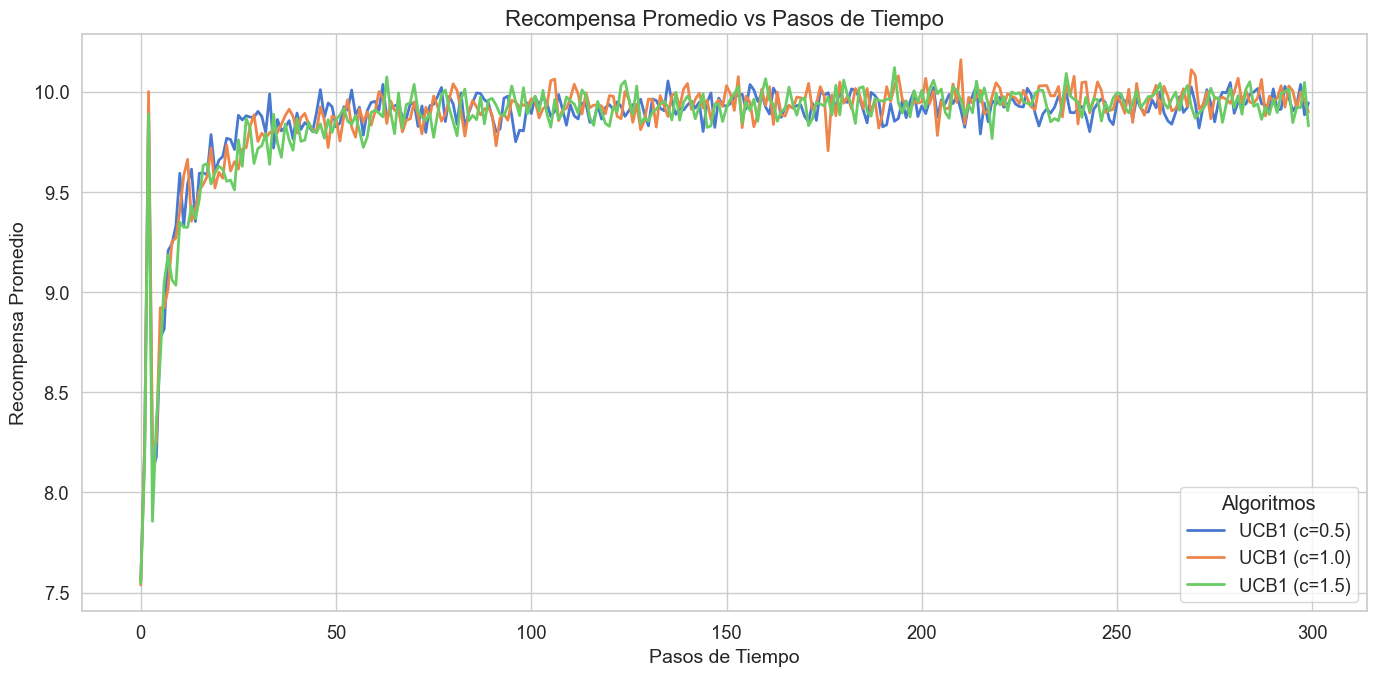

In [38]:
plot_average_rewards(steps, rewards_UCB1, algoritmos_ucb1)

En la gráfica anterior podemos ver el comportamiento del algoritmo UCB1 cuando se modifica su variable de exploración en cada uno de sus 300 pasos. En esta gráfica podemos observar cosas bastante evidentes, como el hecho de que la parametrización de la variable de exploración no afecta de forma palpable al comportamiento de cada una de las curvas.

Respecto a la convergencia, se puede observar que los niveles de convergencia se alcanzan alrededor de los 50 pasos de tiempo y conforme se aumentan los pasos del tiempo no se observa una ganancia sustancial de la recompensa promedio.

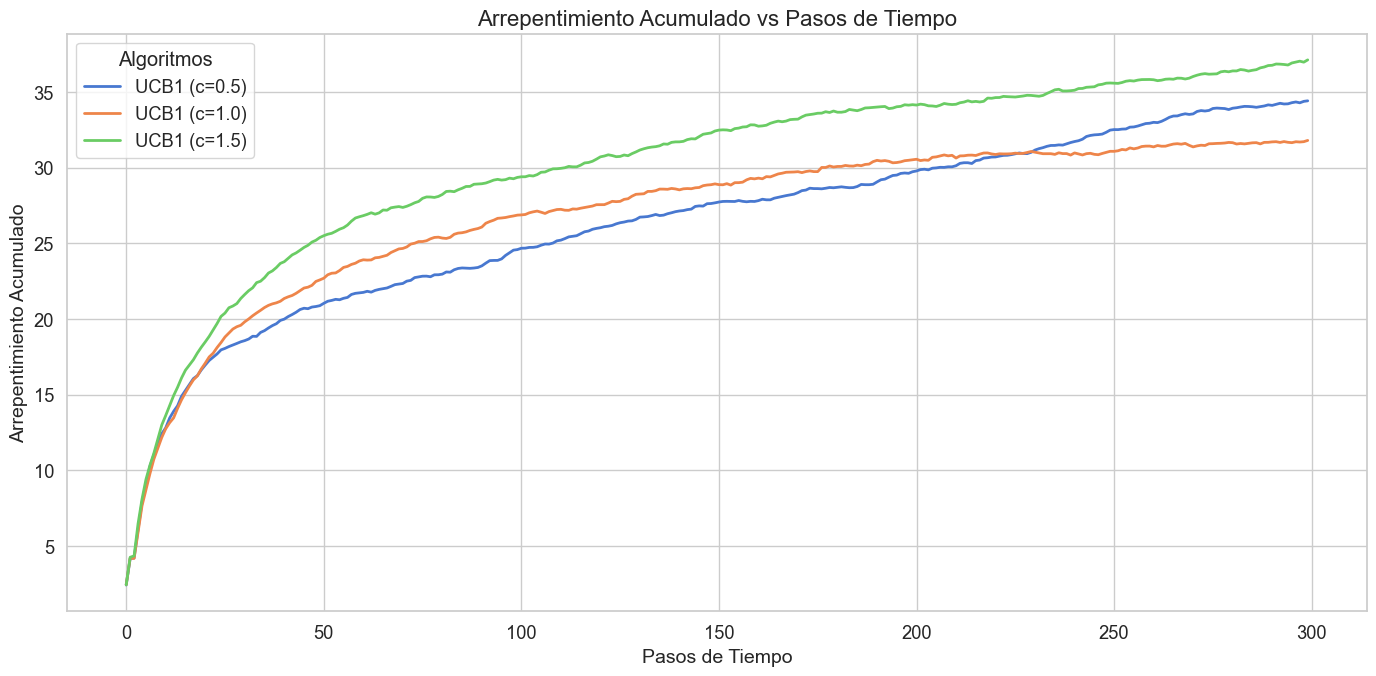

In [39]:
plot_regret(steps, cumulative_regret_per_algo_UCB1, algoritmos_ucb1)

Con esta gráfica, mostramos el arrepentimiento acumulado promedio por cada paso de tiempo en cada algoritmo UCB1 con la variable de exploración parametrizada. El arrepentimiento es una representación de la cuantificación de la perdida por no elegir constantemente el brazo óptimo. Un algoritmo debería de tener el comportamiento de no elegir inicialmente la opción óptima pero conforme se aumentan los pasos de tiempo, la elección del brazo óptimo se debería de producir con mayor frecuencia. Con esta descripción, es fácil asumir que la curva debería seguir una forma logarítmica.

Lo que se puede ver con esta gráfica es que, efectivamente, dicha forma logarítmica se produce en cada caso. Es interesante observar que cuando la variable de exploración es de $0.5$ se produce un comportamiento bastante interesante, concretamente, lo que observamos es que inicialmente el error acumulado es más bajo que cuando la variable de exploración es $1.0$, sin embargo, a partir de aproximadamente 225 pasos, podemos ver que el error acumulado supera al error acumulado de la variable de exploración $1.0$. Con esto podemos decir que los niveles de convergencia de $c=0.5$ se encuentran significativamente más tardíos que cuando $c=1.0$. Podemos observar que cuando la variable de exploración toma el valor por defecto, es el resultado que experimentalmente mejores valores nos da. 

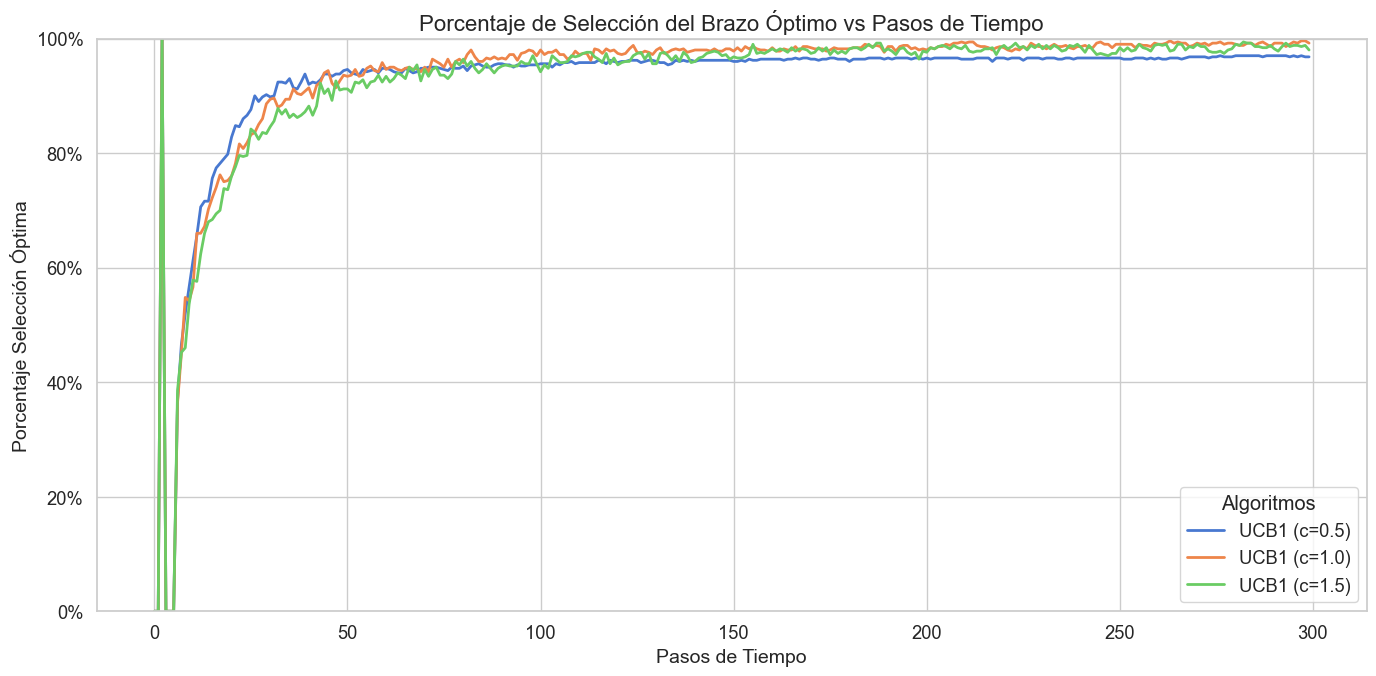

In [40]:
plot_optimal_selections(steps, optimal_selections_UCB1, algoritmos_ucb1)

Con esta gráfica mostramos el porcentaje de veces, dentro de las 500 ejecuciones, que el bandido escogió el brazo óptimo. Podemos observar que son muy parecidas las 3 curvas entre sí rozando prácticamente el 100% del porcentaje de selección del brazo óptimo sobre los 150 pasos de tiempo. Es importante anotar que la curva más distinta dentro de las 3 curvas es aquella en la que el parámetro de exploración $c$ es igual a $0.5$, también es interesante observar que es la que hace convergencia temprana respecto a las 3 curvas y no hace el **spike** observado con las otras 2 curvas.

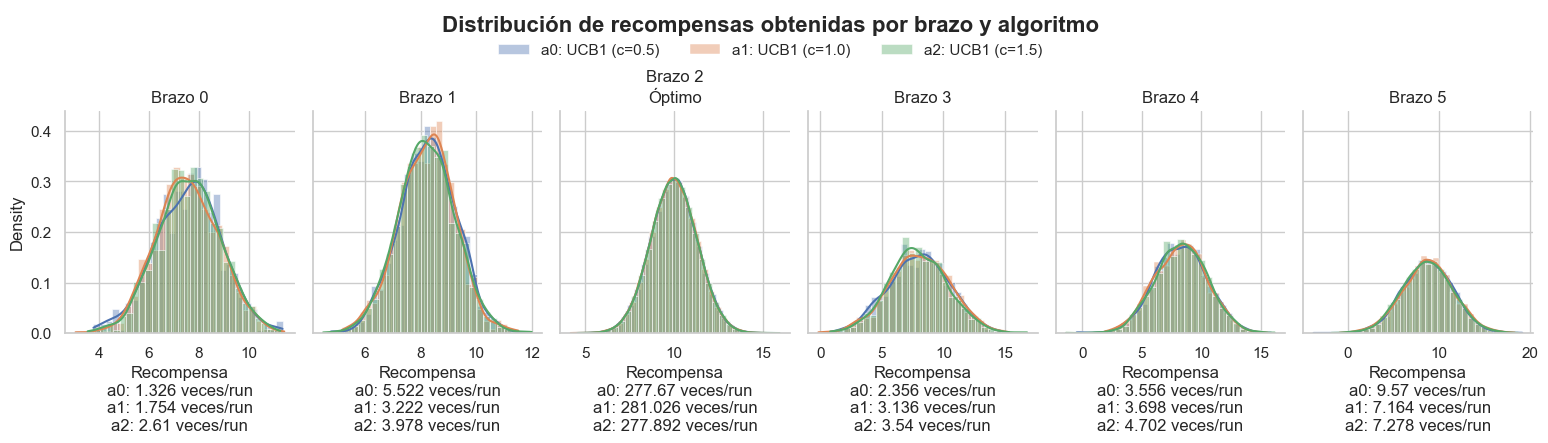

In [41]:
plot_arm_statistics(rewards_per_arm_per_algo_UCB1, algoritmos_ucb1, runs, optimal_arm_normal)

Esta última gráfica es un desglose de distribución de recompensas obtenidas por brazo y por cada algoritmo. Concretamente, mostramos un histograma de la distribución de recompensas obtenidas entre todas las veces que se escoge cada brazo. Mostramos los 3 algoritmos en capas, sin embargo, no se llegan a distinguir del todo dado que las distribuciones son muy parecidas. Se puede observar que el Brazo 0 tiene algunas diferencias entre curvas, además del Brazo 1 y el Brazo 3.

Como podemos observar, el Brazo 2 es el óptimo y, además, es el brazo que se ha elegido más veces por cada algoritmo. Las 3 versiones de UCB1 tienen valores bastante similares de selección, sin embargo, la parametrización de la variable de exploración $c$ cuando es $0.5$ es el que menos veces ha sido seleccionado. El resto de brazos a tavés de las distintas parametrizaciones apenas son seleccionados, en todo caso, podemos decir que el brazo 5 es el segundo brazo más seleccionado.

### Distribución Binomial

Ahora, vamos a repetir los mismos experimentos utilizando el bandido de distribución binomial

In [42]:
np.random.seed(SEMILLA)
rewards_BC1_Bi, optimal_selections_BC1_Bi, cumulative_regret_per_algo_BC1_Bi, rewards_per_arm_per_algo_BC1_Bi = run_experiment(bandit_binomial, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:08<00:00, 56.26it/s]


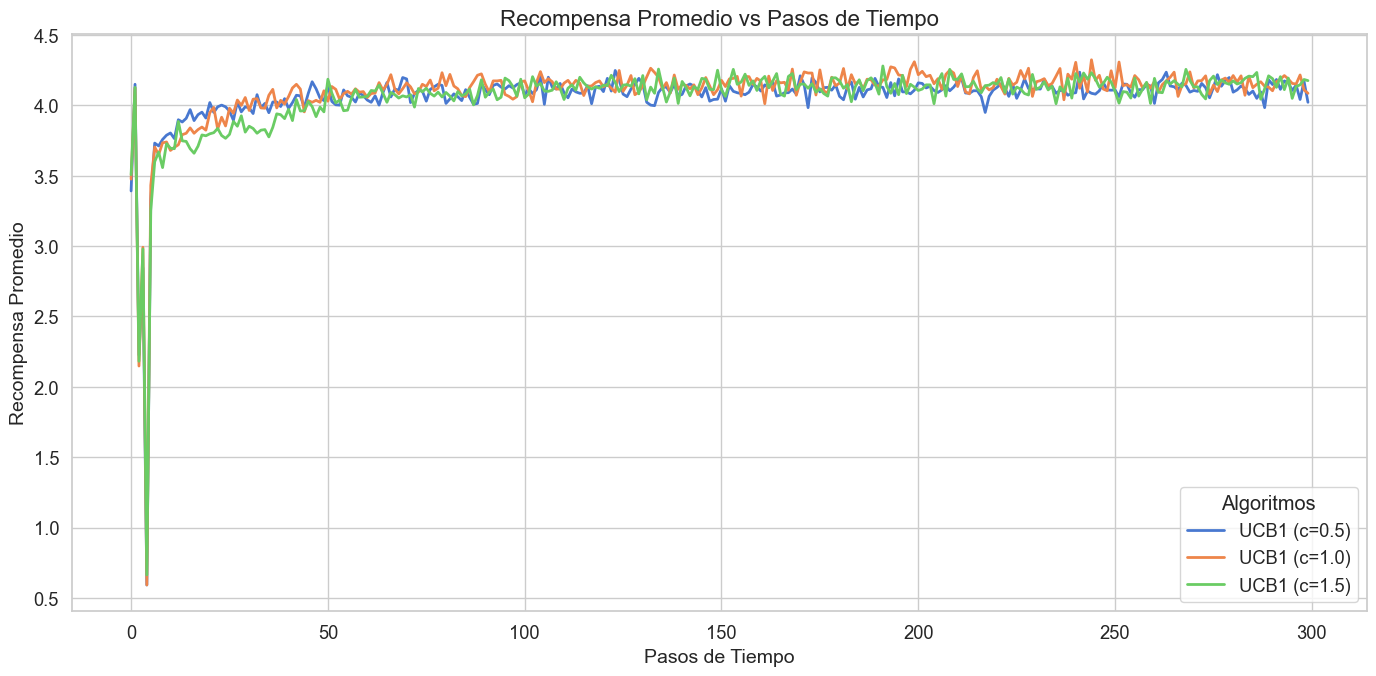

In [43]:
plot_average_rewards(steps, rewards_BC1_Bi, algoritmos_ucb1)

Podemos observar que el comportamiento de la curva se replica respecto a los brazos de distribución normal, es decir, mismos comportamientos independientemente de la parametrización de la variable de exploración y mismos niveles de convergencia. Se puede observar una diferencia clara respecto al anterior brazo, y es que las recompensas medias obtenidas son mucho menores debido a los valores de $n$ y $p$ que hemos elegido para los brazos.

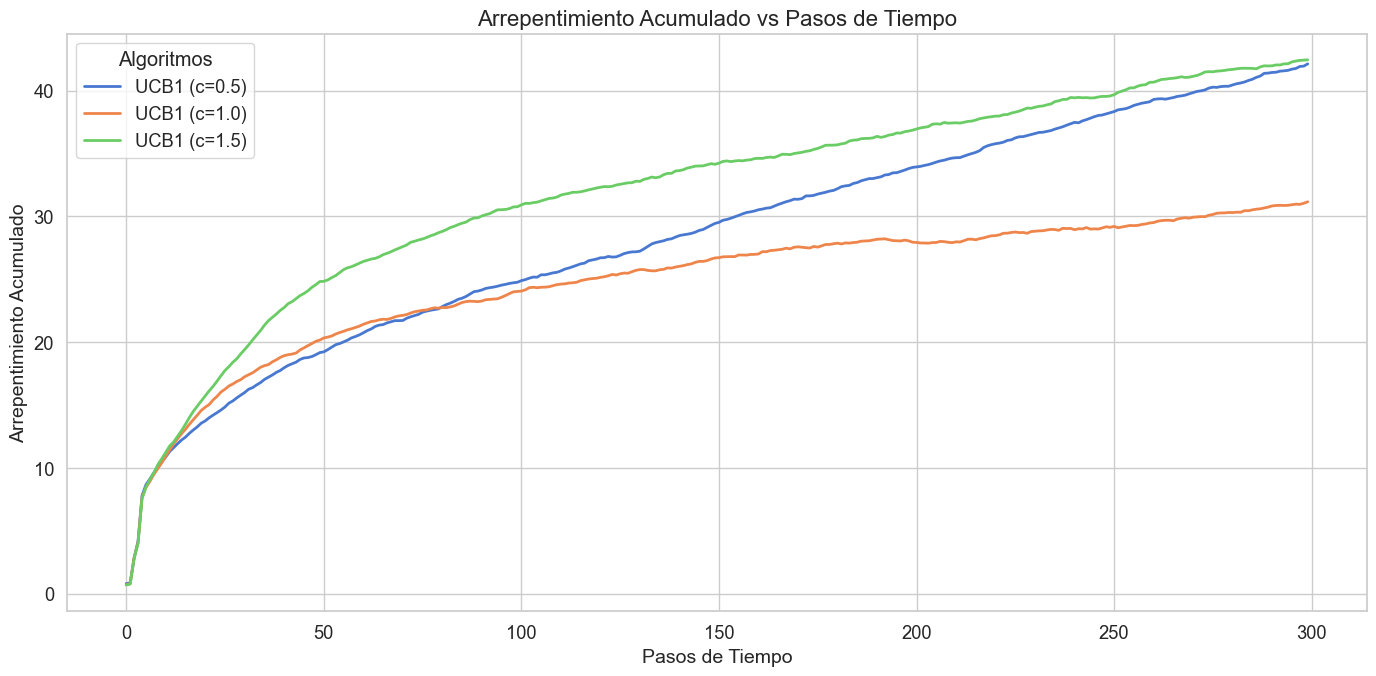

In [44]:
plot_regret(steps, cumulative_regret_per_algo_BC1_Bi, algoritmos_ucb1)

La gráfica del arrepentimiento muestra un comportamiento bastante interesante respecto a la anterior gráfica. Podemos observar que, nuevamente, la versión que mejor curva de arrepentimiento muestra es aquella en la que la variable de exploración se mantiene a $1.0$, sin embargo, podemos ver que inicialmente cuando nuestra variable de exploración es $0.5$, los valores de arrepentimiento son los mejores, pero rápidamente, en torno a 75 pasos de tiempo es peor que la variable de exploración $1.0$ e incluso si se dejara en ejecución más pasos de tiempo con una gran probabilidad sería la peor versión de las 3 curvas expuestas.

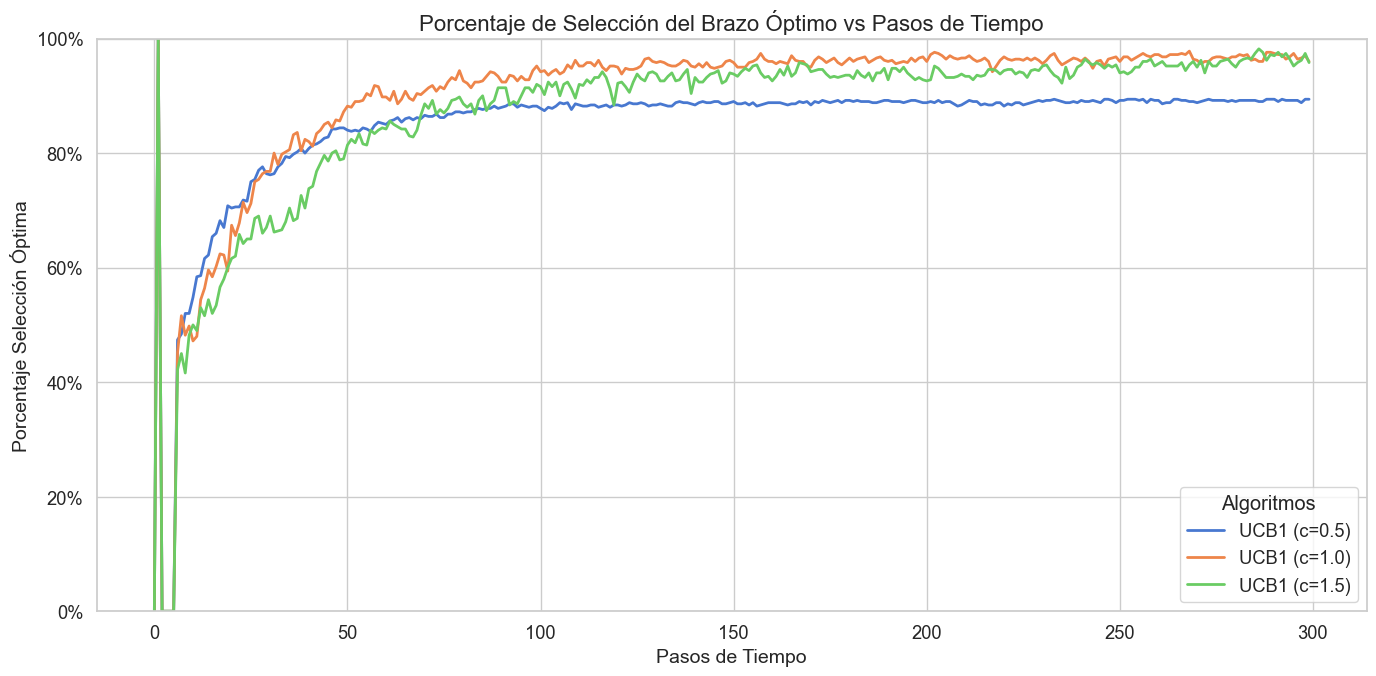

In [45]:
plot_optimal_selections(steps, optimal_selections_BC1_Bi, algoritmos_ucb1)

Observamos nuevamente que las curvas de UCB1 con las variables de exploración $1.5$ o $1.0$ son claramente superiores a cuando la variable de exploración es $0.5$. También observamos que si bien nos encontramos cerca del 100% del porcentaje de selección del brazo óptimo en las 3 curvas, podemos ver que sus puntos de convergencia se sitúan ligeramente por debajo que lo expuestos con la distribución normal. UCB1 cuando su variable de exploración es $0.5$ muestra más diferencias que el resto de curvas, situándose por debajo del 90% en su convergencia. Con esto, podemos concluir que cuando nuestra variable de exploración es concretamente $1.0$ es cuando el algoritmo mejor aprende.

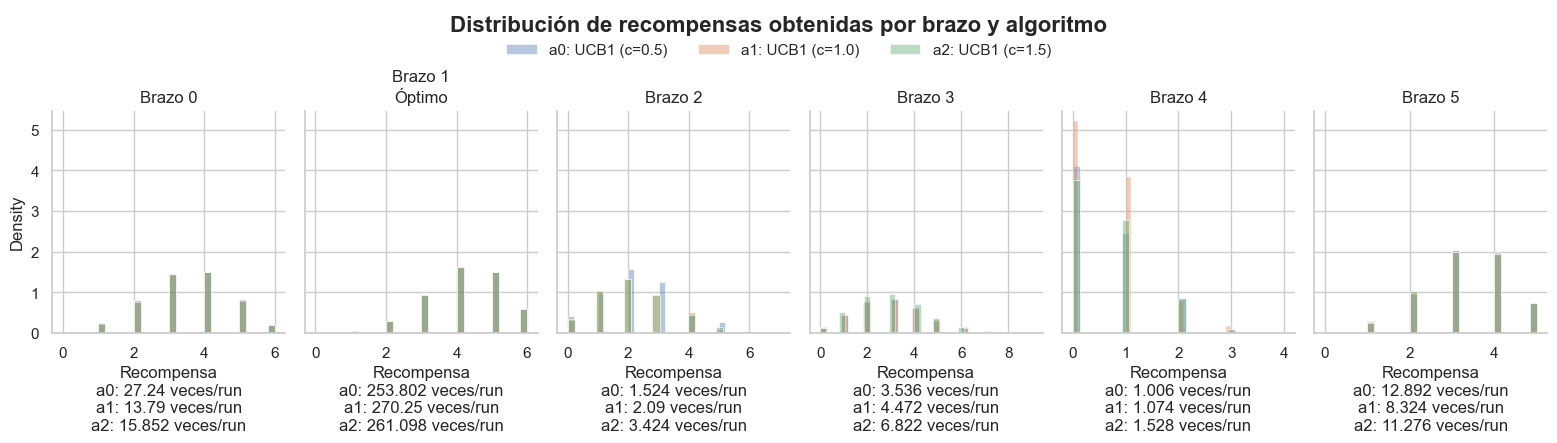

In [46]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1_Bi, algoritmos_ucb1, runs, optimal_arm_binomial, kde=False)

Con esta última gráfica se vuelve a ver en cierta manera el mismo patrón que con la distribución normal, es decir, el brazo óptimo tiene una alta tendencia a ser elegido, siendo éste el Brazo 1. Podemos observar, eso si, una diferencia bastante palpable respecto a la distribución normal, y es que uno de los brazos no óptimos es seleccionado bastante más veces que en cualquier otro brazo de la distribución normal. También podemos ver que los brazos no siguen una distribución continua, sino que estamos ante una distribución con resultados discretos.

Nuevamente, al igual que con los brazos de distribución normal, el brazo con la variable de exploración escogida a $0.5$ tiene tendencia a elegir bastante más veces el brazo equivocado, con la excepción del Brazo 3 y del Brazo 4, donde son elegidos con más frecuencia con la variable de exploración a $1.5$.

### Distribución Bernoulli

Para terminar con el primer algoritmo de la familia de UCB, vamos a comprobar cómo se comporta con la distribución de Bernoulli.

In [47]:
np.random.seed(SEMILLA)
rewards_BC1_Be, optimal_selections_BC1_Be, cumulative_regret_per_algo_BC1_Be, rewards_per_arm_per_algo_BC1_Be = run_experiment(bandit_bernoulli, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:08<00:00, 55.75it/s]


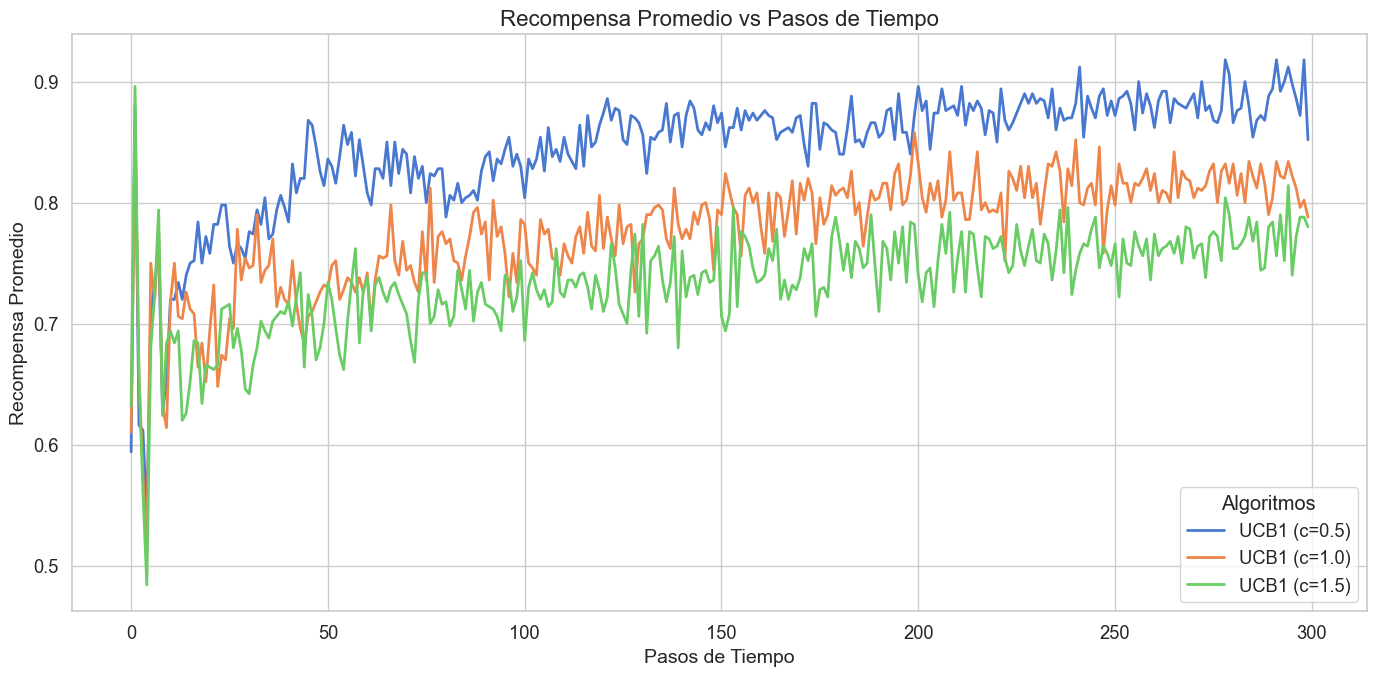

In [48]:
plot_average_rewards(steps, rewards_BC1_Be, algoritmos_ucb1)

En este caso sí que se pueden evidenciar diferencias palpables con solamente analizar las recompensas promedio del algoritmo UCB1. Concretamente, observamos que la mejor versión para la distribución Bernoulli resulta de utilizar como variable de exploración $c=0.5$. De forma general se observa que los niveles de convergencia se consiguen de forma bastante más tardía que con los otros brazos, obteniéndose en torno a los 200 pasos. También se palpa una mayor inestabilidad con **spikes** a lo largo de las 3 parametrizaciones realizadas, indicando que al bandido a través de los 3 casos de estudio le cuesta más aprender aquel brazo que sea óptimo.

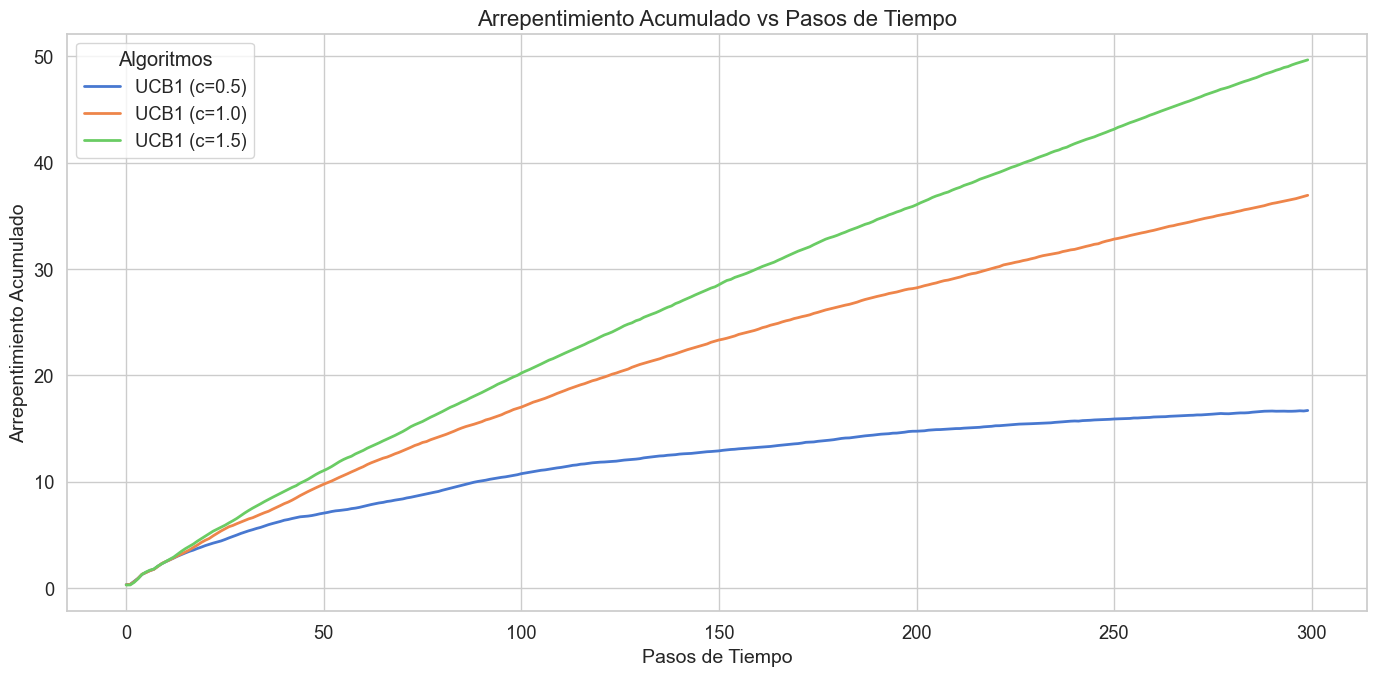

In [49]:
plot_regret(steps, cumulative_regret_per_algo_BC1_Be, algoritmos_ucb1)

Podemos ver que las curvas del arrepentimiento siguen exactamente los mismos patrones que la distribución binomial, haciendo que muy probablemente sea UCB1 con $c=0.5$ el peor valor y siendo UCB1 con el valor por defecto de exploración el mejor.

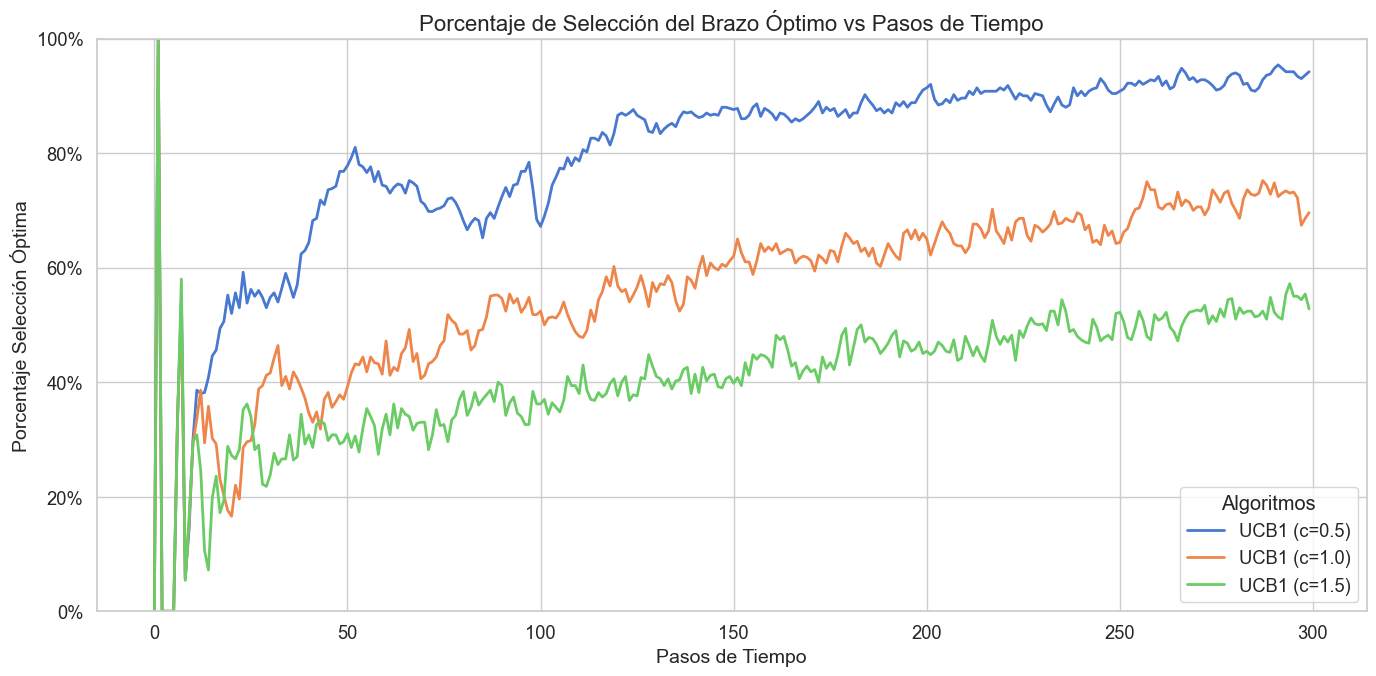

In [50]:
plot_optimal_selections(steps, optimal_selections_BC1_Be, algoritmos_ucb1)

Se puede evidenciar que, claramente, el mejor brazo respecto al porcentaje de selección del brazo óptimo pasa por elegir UCB1 cuando la variable de exploración $c$ es $0.5$ para esta distribución. Además, esto se da por gran margen, dado que el algoritmo con la siguiente mejor variable de exploración no consigue llegar al 80% de selección del brazo óptimo, mientras que con la mejor se llega a rozar el 98%.

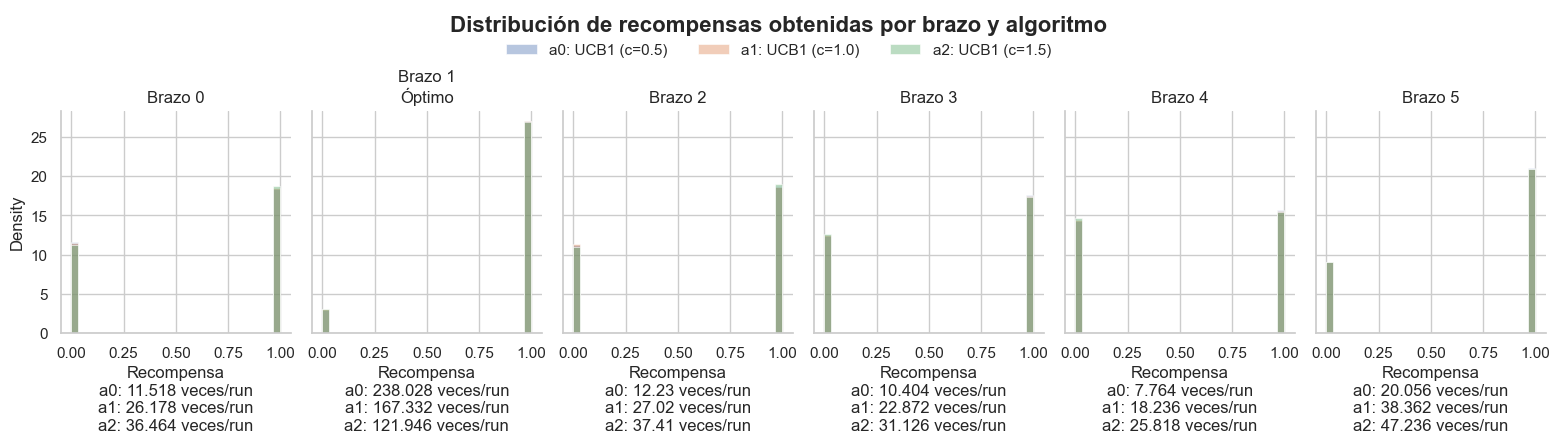

In [51]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1_Be, algoritmos_ucb1, runs, optimal_arm_bernoulli, kde=False)

Para terminar, el brazo óptimo es el que evidentemente más se selecciona, mientras que el resto de brazos se eligen mucho menos. Se aprecia claramente cómo el parámetro $c=0.5$ logra reconocer el brazo óptimo mucho mejor que los otros dos, que reparten sus acciones más entre algunos de los brazos sub-óptimos, como el 0, el 2 o el 5.

Con todo esto podemos observar que las salidas producidas son muy parecidas que cuando tenemos distribuciones binomiales o normales, sin embargo, el mejor comportamiento dentro de todos los existentes para este algoritmo es el de los bandidos con distribución normal.

## Análisis UCB2

En esta sección nos dedicamos al estudio del segundo algoritmo de la familia UCB (UCB2) con todos los tipos de bandidos. Para cada uno, vamos a ejecutar el algoritmo con valores distintos del parámetro $\alpha$ comprendidos entre $0$ y $1$, concretamente: $0.25$, $0.5$, $0.75$.

In [52]:
algoritmos_ucb2 = [UCB2(k=k, alpha=0.25), UCB2(k=k, alpha=0.5), UCB2(k=k, alpha=0.75)]

### Distribución Normal

En primer lugar, vamos a realizar las ejecuciones de todos los algoritmos con el bandido cuyos brazos siguen la distribución normal.

In [53]:
np.random.seed(SEMILLA)
rewards_UCB2, optimal_selections_UCB2, cumulative_regret_per_algo_UCB2, rewards_per_arm_per_algo_UCB2 = run_experiment(bandit_normal, algoritmos_ucb2, steps, runs)

  0%|          | 0/500 [00:00<?, ?it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:04<00:00, 119.09it/s]


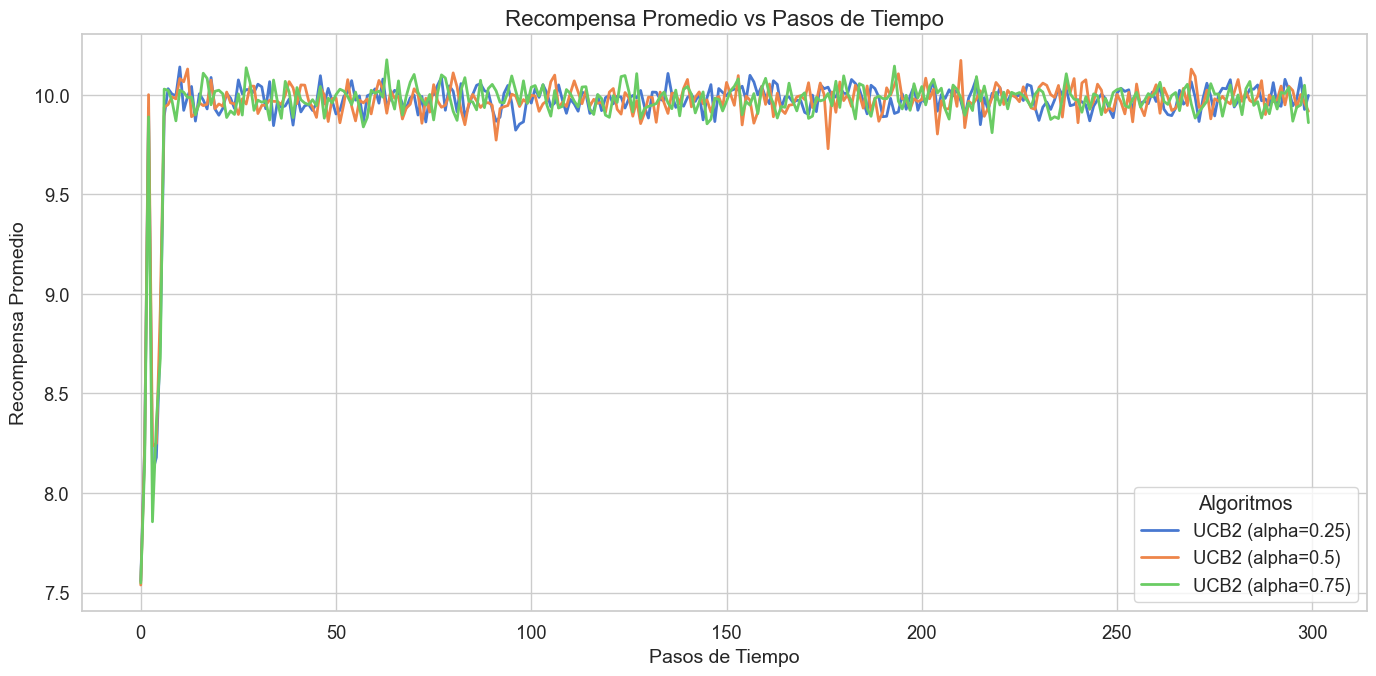

In [54]:
plot_average_rewards(steps, rewards_UCB2, algoritmos_ucb2)

Con la segunda iteración del algoritmo UCB, es decir, UCB2, podemos observar que los niveles de convergencia se hacen en prácticamente menos de 20 épocas con cualquier valor escogido para nuestro $\alpha$. Esto demuestra la superioridad que este este algoritmo frente a UCB1. La velocidad de aprendizaje es extremadamente alta.

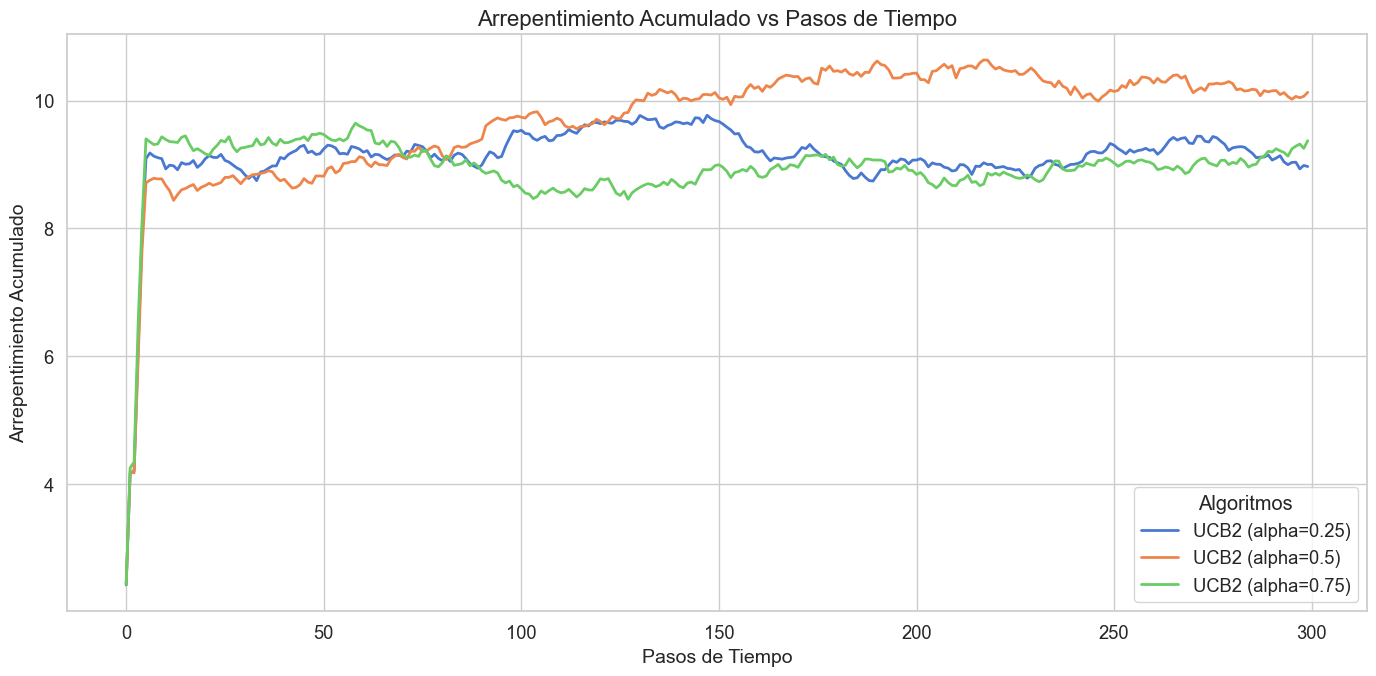

In [55]:
plot_regret(steps, cumulative_regret_per_algo_UCB2, algoritmos_ucb2)

Respecto al arrepentimiento, vemos claramente la enorme superioridad de UCB2 con respecto a UCB1, mostrando unas curvas de arrepentimiento prácticamente horizontales a partir de cierto punto, lo cual indica que los algoritmos han identificado perfectamente cuál es el brazo óptimo y solo lo han elegido a él, ignorando al resto de brazos. Por ende, una vez se ha acumulado el error de las primeras iteraciones, este deja de incrementar por completo.

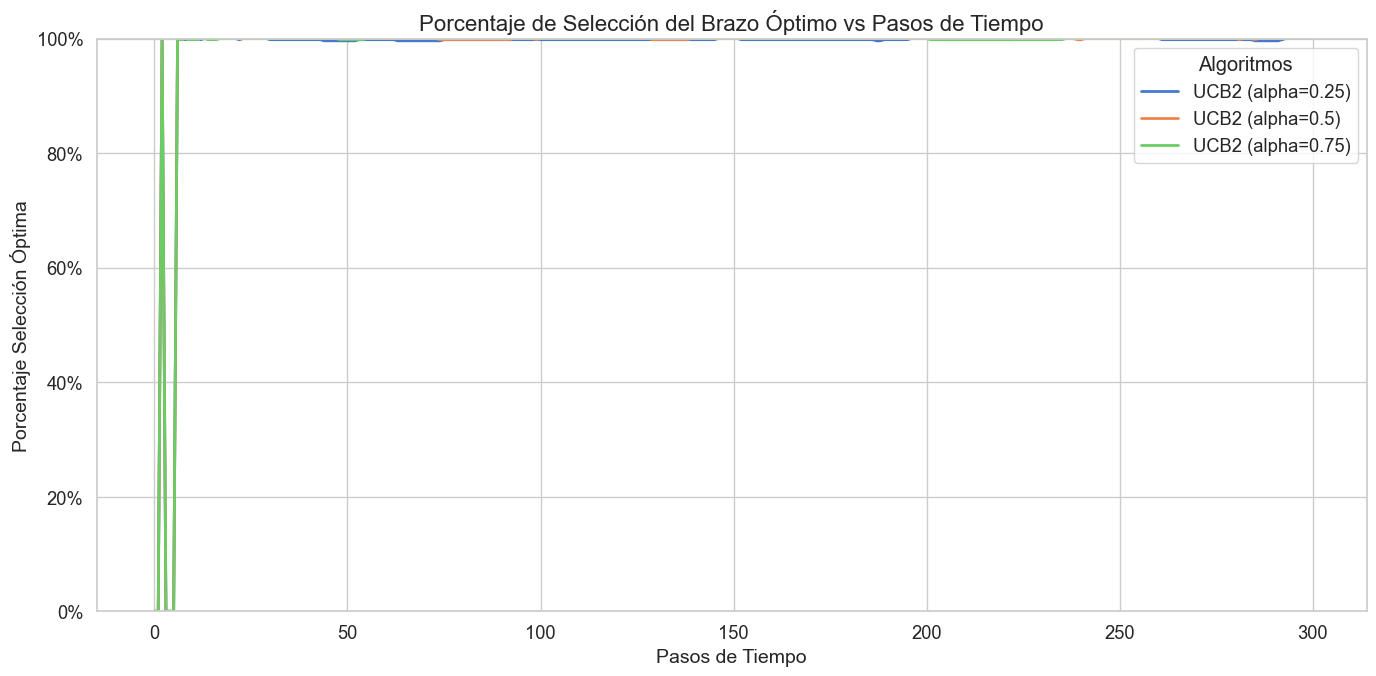

In [56]:
plot_optimal_selections(steps, optimal_selections_UCB2, algoritmos_ucb2)

Respecto al porcentaje de selección del brazo óptimo a lo largo de los pasos del tiempo, podemos observar que de forma general se selecciona desde los niveles de convergencia el brazo óptimo, como ya habíamos mencionado antes. Todas las versiones de UCB2 se sitúan en un porcentaje de prácticamente el 100% a partir de las primeras iteraciones.

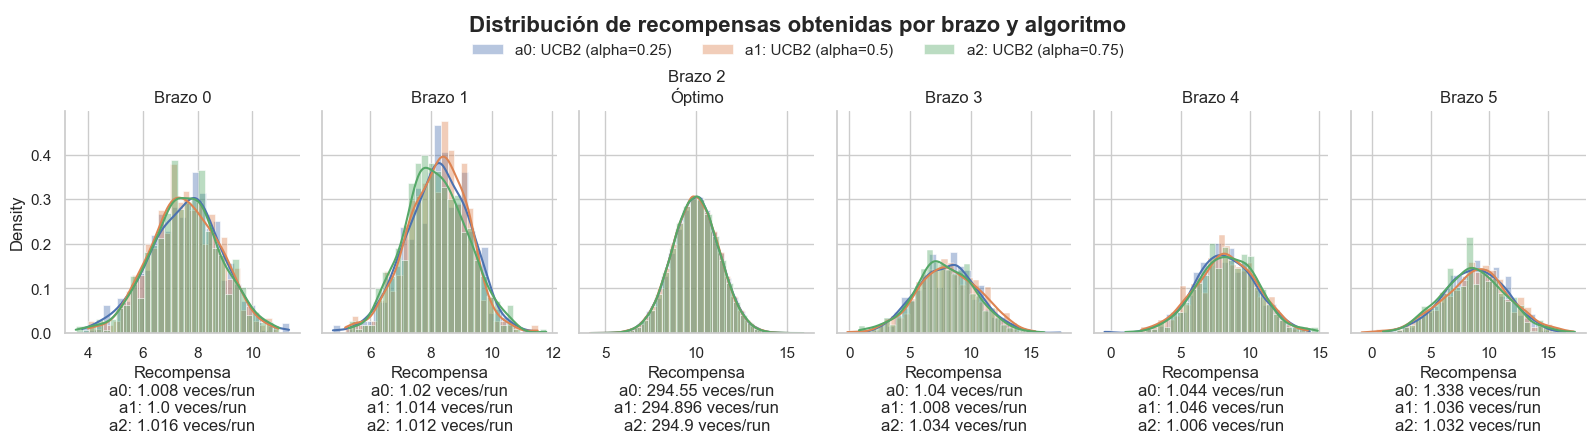

In [57]:
plot_arm_statistics(rewards_per_arm_per_algo_UCB2, algoritmos_ucb2, runs, optimal_arm_normal)

Podemos comprobar con la distribución de recompensas que casi siempre se selecciona el brazo 2 como brazo óptimo, y de forma extremadamente casual se selecciona cualquier otro brazo. En media, los brazos no óptimos se seleccionan 1 vez por cada ejecución y sus distribuciones son un tanto anomalas respecto a las del brazo óptimo a consecuencia de la falta de datos de dicho brazo para poder dibujar más concretamente su distribución. El motivo por el cual el resto de brazos no óptimos se seleccionan alrededor de 1 vez por ejecución es por la fase de inicialización que hemos implementado, en la que el agente escoge cada brazo una vez para asegurarse de probarlos todos.

### Distribución Binomial

Ahora, es el turno del análisis de UCB2 cuando se aplica la distribución binomial.

In [58]:
np.random.seed(SEMILLA)
rewards_BC2_Bi, optimal_selections_BC2_Bi, cumulative_regret_per_algo_BC2_Bi, rewards_per_arm_per_algo_BC2_Bi = run_experiment(bandit_binomial, algoritmos_ucb2, steps, runs)

 14%|█▍        | 72/500 [00:00<00:03, 113.45it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:04<00:00, 113.95it/s]


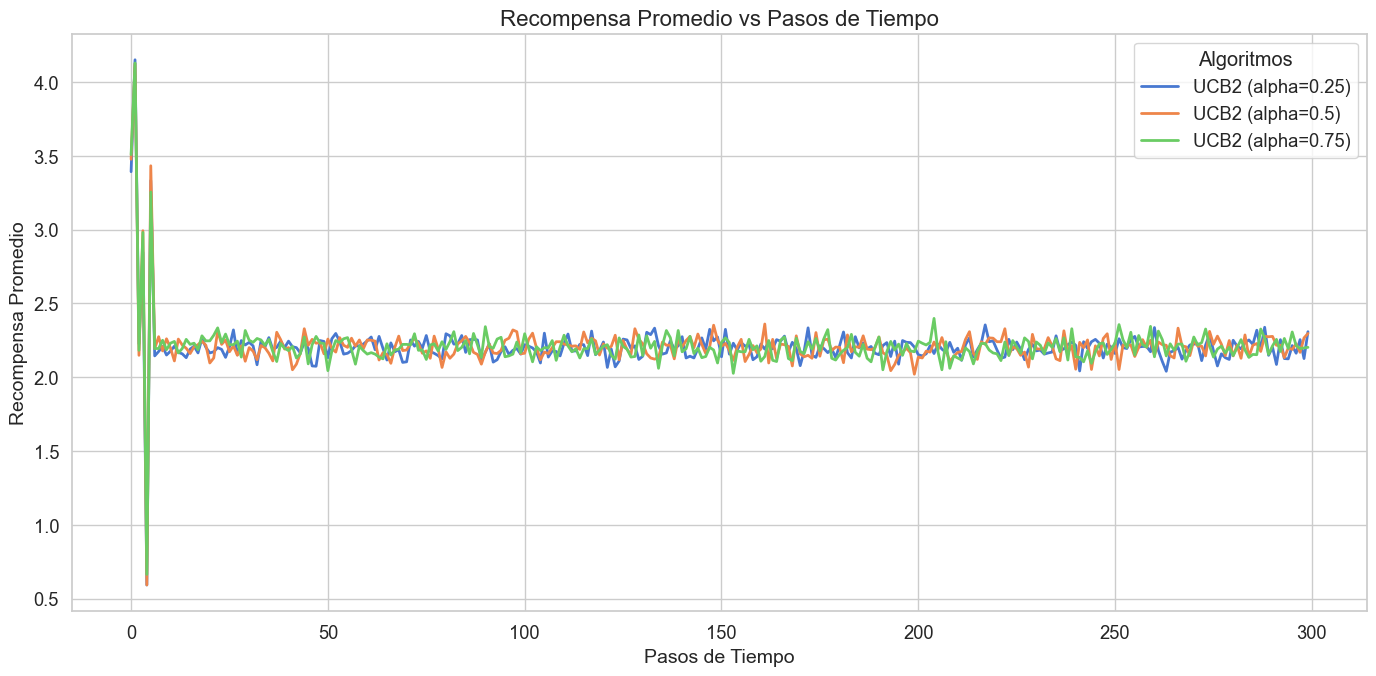

In [59]:
plot_average_rewards(steps, rewards_BC2_Bi, algoritmos_ucb2)

Podemos observar que las recompensas obtenidas son totalmente anómalas que las obtenidas en cualquier distribución de bandido con UCB1 o que con UCB2 con la distribución normal. Concretamente, lo que observamos es un estancamiento claro del algoritmo que no es capaz de aprender correctamente, haciendo convergencia de forma bastante precoz y manteniéndose a niveles constantes. Claramente, observamos que el aprendizaje que realiza el bandido es bastante malo. El patrón se repite independientemente de los valores elegidos para la variable $\alpha$.

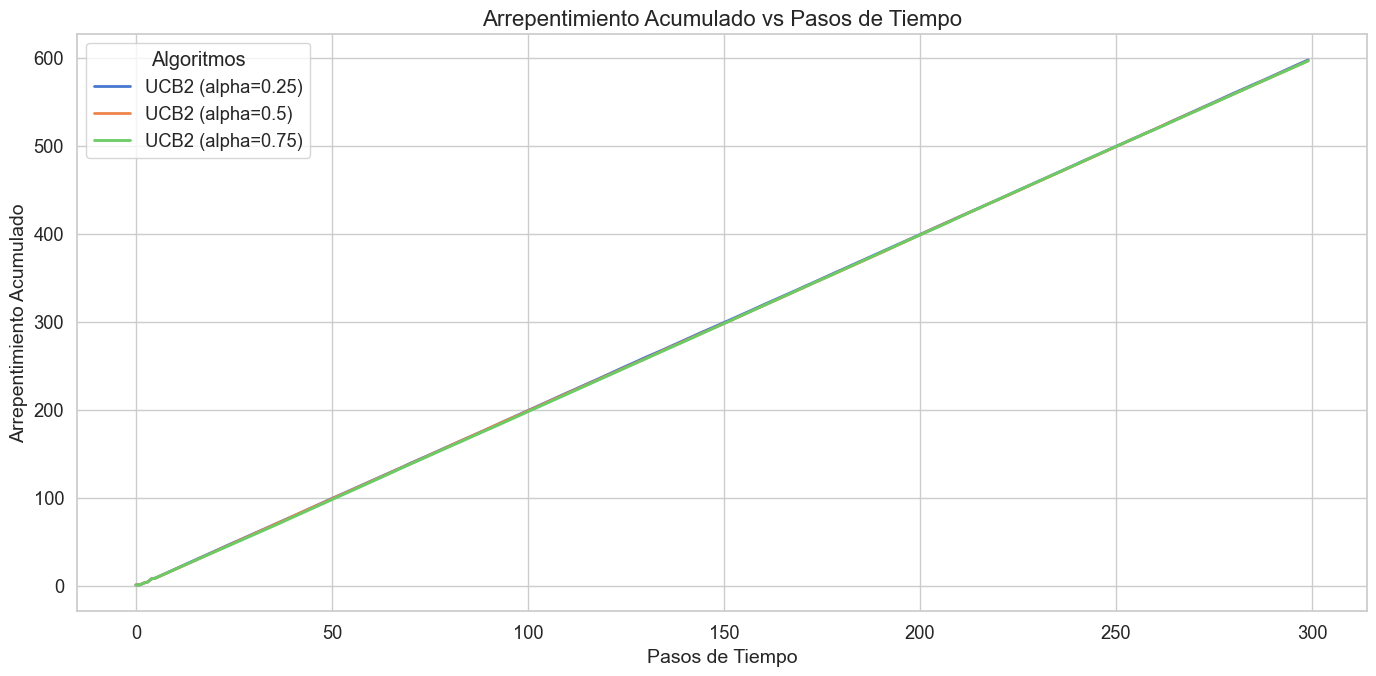

In [60]:
plot_regret(steps, cumulative_regret_per_algo_BC2_Bi, algoritmos_ucb2)

Podemos ver que ya no se respeta la curva del arrepentimiento descrita en cualquiera de los ejemplos ejecutados anteriormente. Esta vez, lo que se observa es una línea totalmente recta conforme se avanzan en los pasos que es prácticamente idéntica con independencia de los valores escogidos para la variable $\alpha$, algo que evidencia el mal aprendizajee que realiza nuestro bandido.

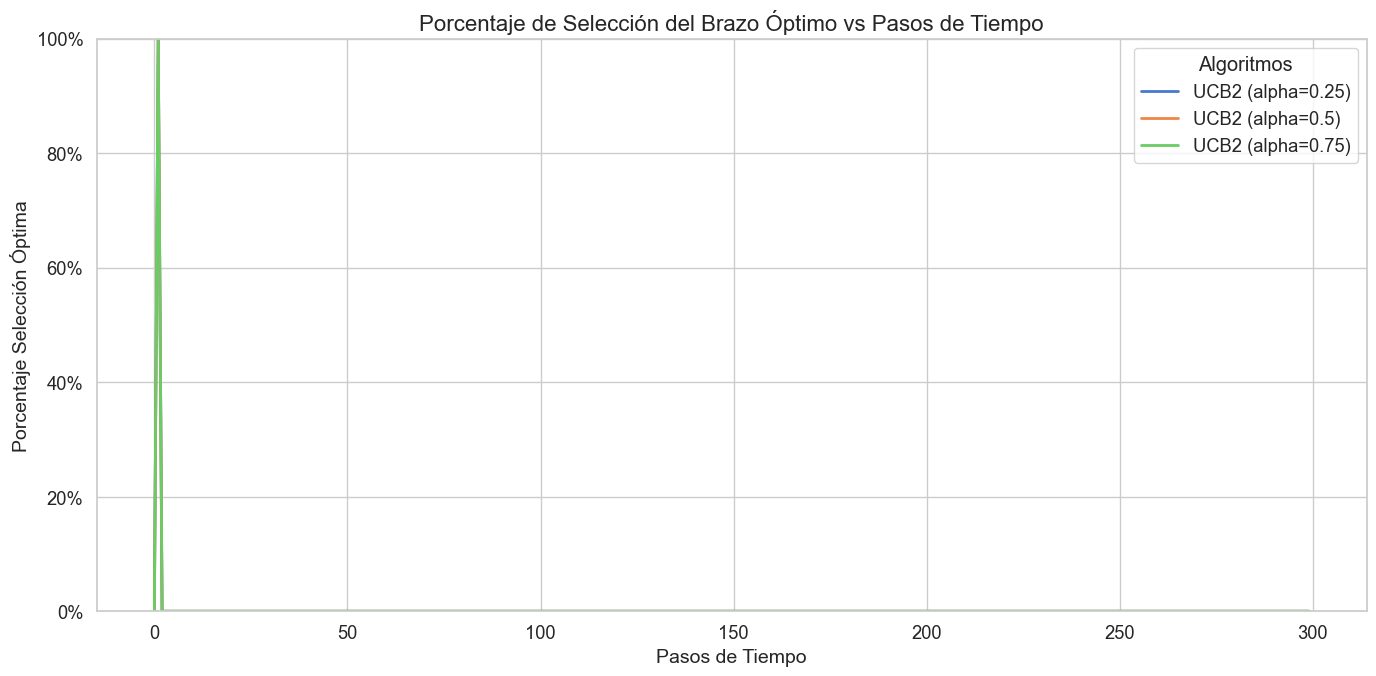

In [61]:
plot_optimal_selections(steps, optimal_selections_BC2_Bi, algoritmos_ucb2)

Podemos observar con este algoritmo que nunca se elige el brazo óptimo a excepción de en la fase de inicialización.

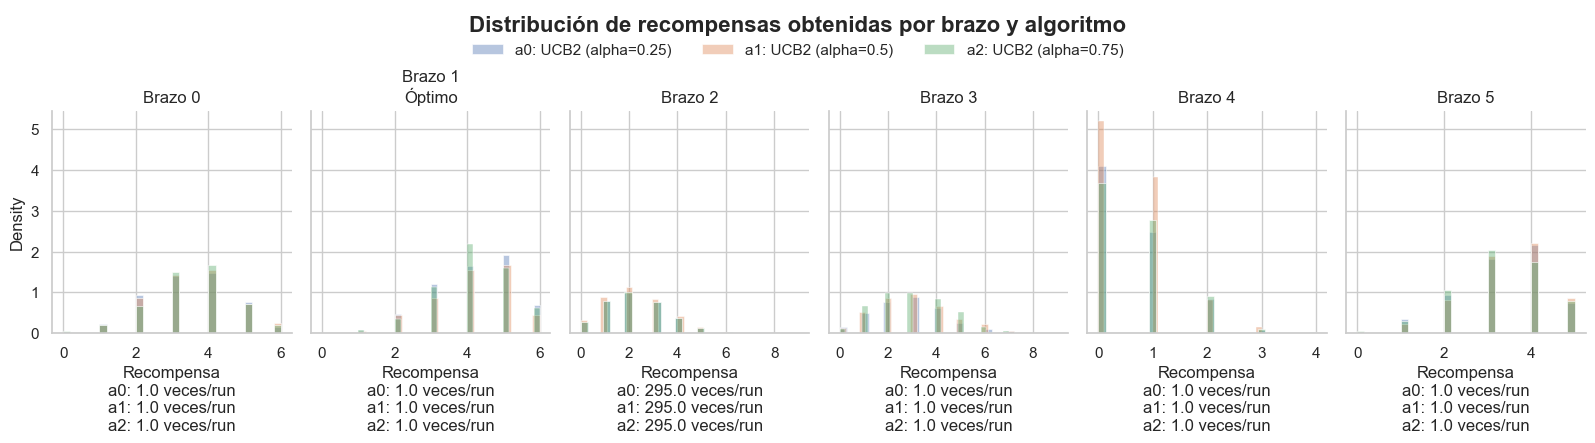

In [62]:
plot_arm_statistics(rewards_per_arm_per_algo_BC2_Bi, algoritmos_ucb2, runs, optimal_arm_binomial, kde=False)

Con esta gráfica podemos ver exactamente qué es lo que esta ocurriendo. Concretamente, lo que sucede es que se está escogiendo consistentemente el brazo 2, que no es óptimo. También podemos ver que las veces que cada brazo es escogido a lo largo de todas las parametrizaciones de UCB2 es el mismo, es decir, cada brazo es escogido 1 vez, salvo el 2, que es escogido el resto de veces. Con esto se evidencia que los brazos de distribución Binomial junto al algoritmo UCB2 resulta ser una muy mala combinación para resolver el problema del bandido.

### Distribución Bernoulli

Para finalizar el análisis de UCB2, pasemos a observar qué tal se comporta este algoritmo con la distribución de Bernoulli.

In [63]:
np.random.seed(SEMILLA)
rewards_BC2_Be, optimal_selections_BC2_Be, cumulative_regret_per_algo_BC2_Be, rewards_per_arm_per_algo_BC2_Be = run_experiment(bandit_bernoulli, algoritmos_ucb2, steps, runs)

  0%|          | 0/500 [00:00<?, ?it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:04<00:00, 121.92it/s]


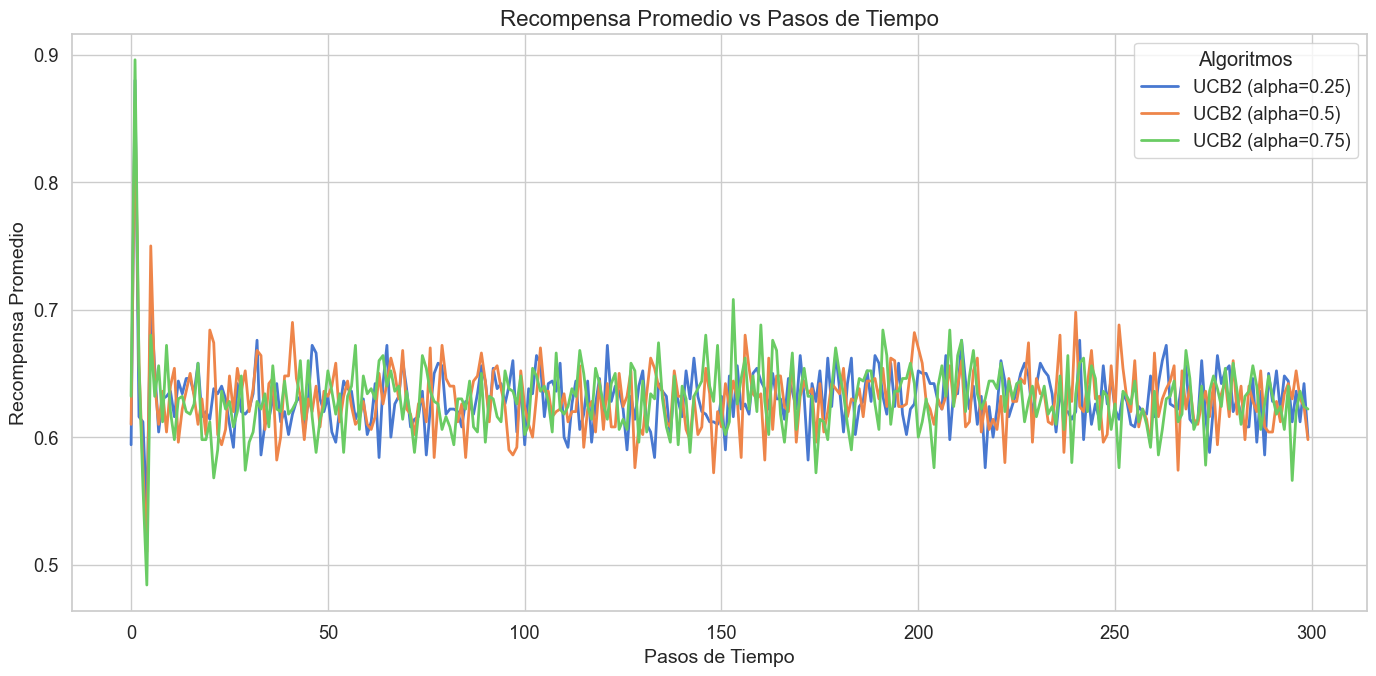

In [64]:
plot_average_rewards(steps, rewards_BC2_Be, algoritmos_ucb2)

Nuevamente, al igual que con la versión de la distribución de la Binomial, vemos un estancamiento generalizado del aprendizaje, sin embargo, a diferencia de la distribución Binomial, este estancamiento se produce en valores aún más bajos, es decir, en vez de encontrarnos en una situación de estancamiento en torno a $2.25$, nos encontramos en un estancamiento de recompensa promedio entorno al valor $0.65$ (que es *proporcionalmente* inferior). Esto indica que muy probablemente estemos escogiendo aún peores brazos que los escogidos con la distribución binomial. También vemos, al igual que con la distribución binomial, que independientemente de la versión del algoritmo que hayamos escogido los valores producidos son los mismos.

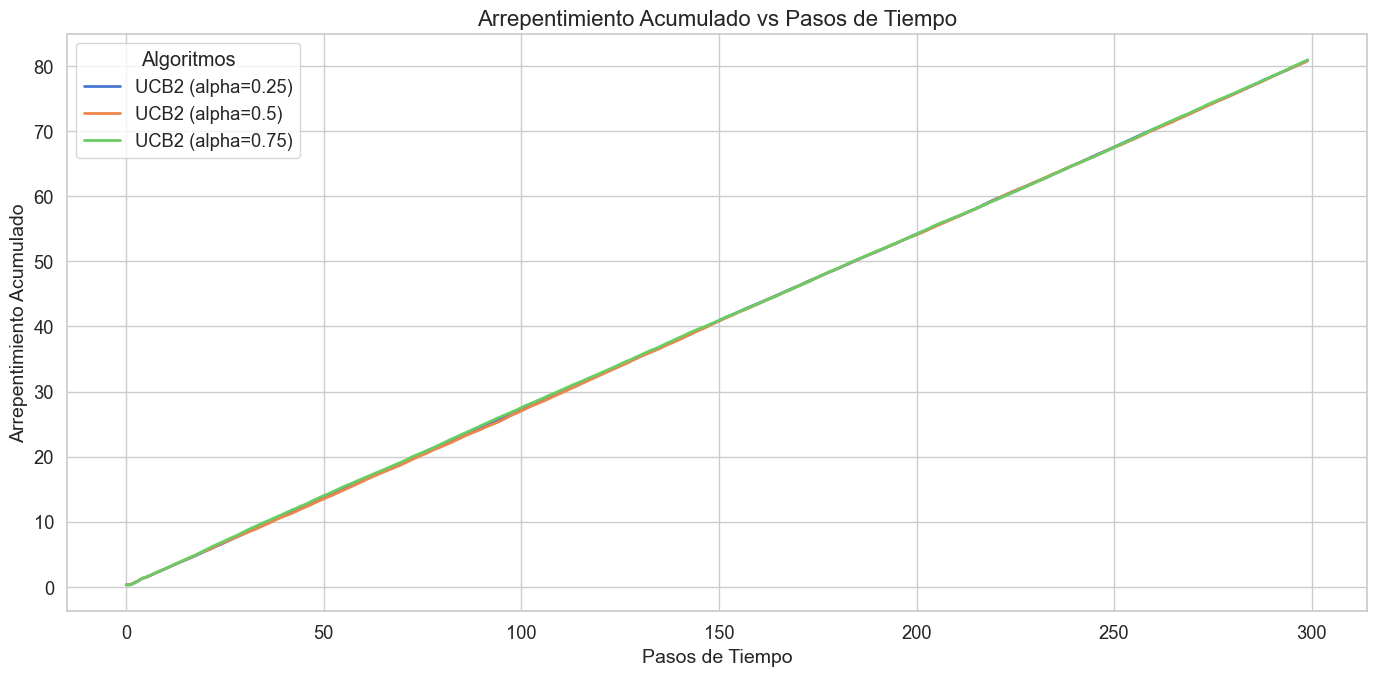

In [65]:
plot_regret(steps, cumulative_regret_per_algo_BC2_Be, algoritmos_ucb2)

Tal y como se produce con el sistema de distribución Binomial, el arrepentimietno acumulado producido sigue una línea perfectamente recta que se replica con independencia de la versión del algoritmo parametrizado que utilicemos.

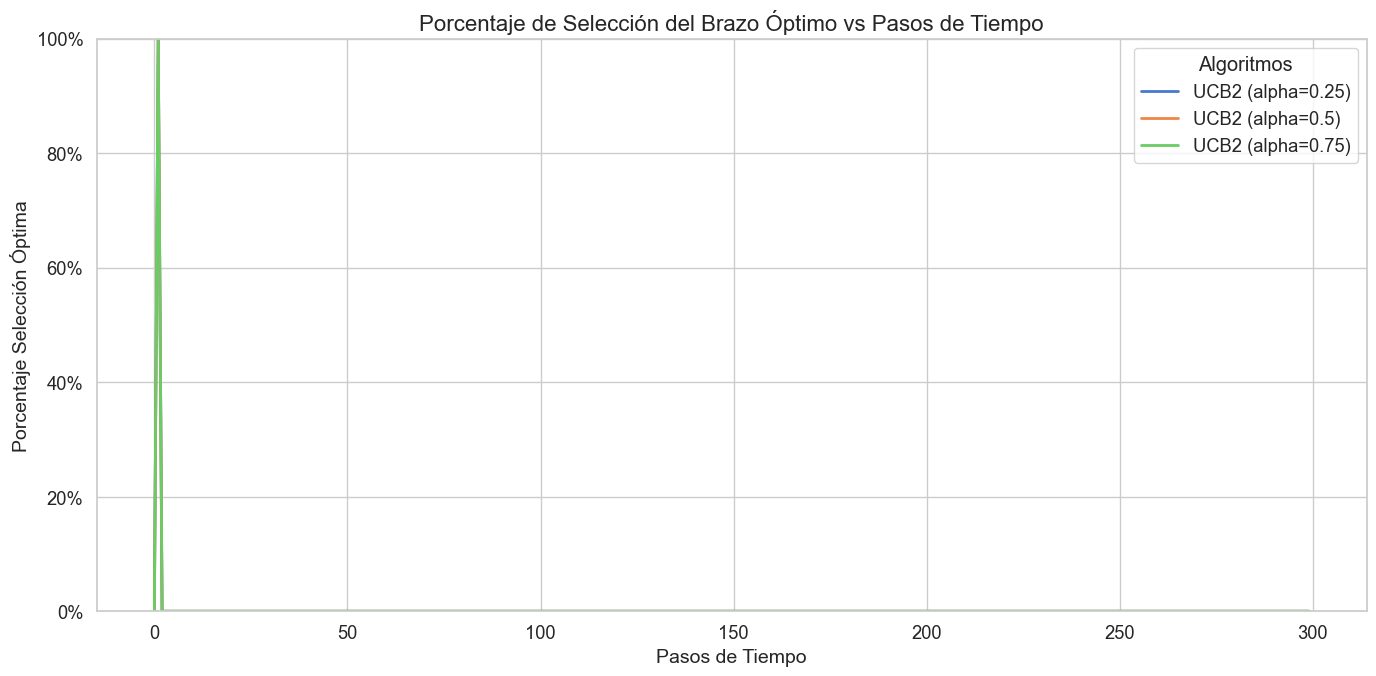

In [66]:
plot_optimal_selections(steps, optimal_selections_BC2_Be, algoritmos_ucb2)

Nuevamente, podemos ver que lo que esperábamos se cumple, es decir, nunca es seleccionado el brazo óptimo, únicamente en aquel intante en el que se exploran todos y cada uno de los brazos que contenga nuestro bandido, pero nunca se vuelve a seleccionar el brazo óptimo.

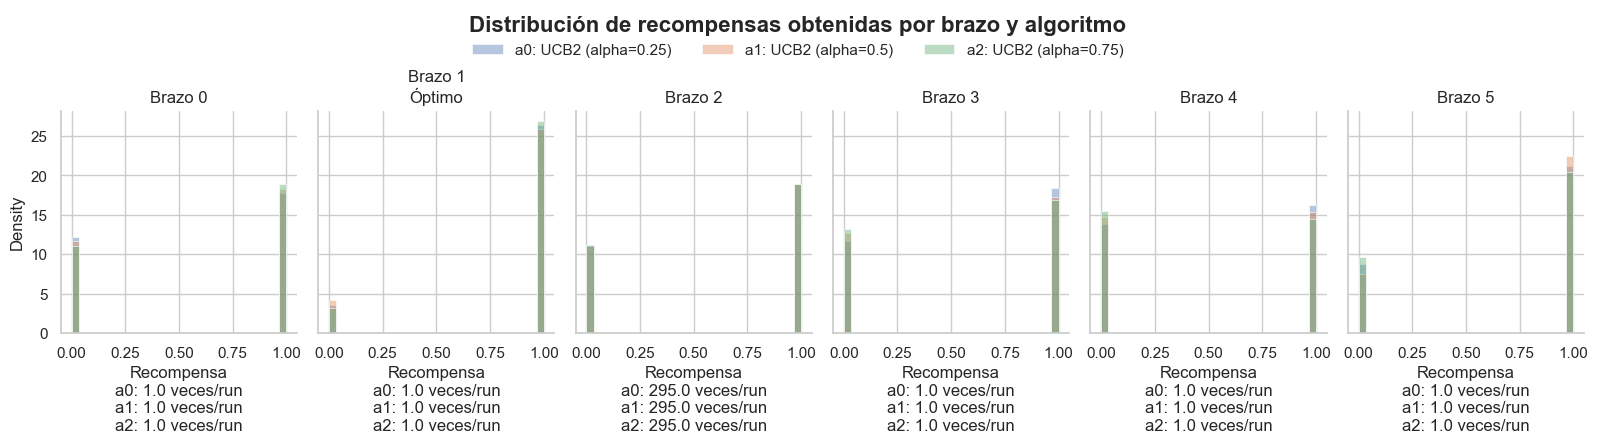

In [67]:
plot_arm_statistics(rewards_per_arm_per_algo_BC2_Be, algoritmos_ucb2, runs, optimal_arm_bernoulli, kde=False)

Observamos un comportamiento muy parecido a la distribución Binomial: todos los brazos se escogen una vez a excepción de uno de ellos, el Brazo 2, que se elige el resto de las veces. Las tres parametrizaciones generan los mismos resultados. En definitiva, lo que observamos es que UCB2 se comporta extraordinariamente bien para brazos con recompensas continuas, pero excesivamente mal para brazos con recompensas discretas.

## Análisis UCB1-Tuned

En esta sección nos dedicamos al análisis del último algoritmo de la familia UCB que analizamos con este estudio, es decir, UCB1-Tuned. Este modelo no contiene variables parametrizables, por tanto, vamos a realizar una única ejecución.

In [68]:
algoritmos_UCB1Tuned = [UCB1Tuned(k=k)]

### Distribución Normal

Pasemos a realizar el análisis con el bandido cuyos brazos sigan la distribución normal

In [69]:
np.random.seed(SEMILLA)
rewards_UCB1Tuned, optimal_selections_UCB1Tuned, cumulative_regret_per_algo_UCB1Tuned, rewards_per_arm_per_algo_UCB1Tuned = run_experiment(bandit_normal, algoritmos_UCB1Tuned, steps, runs)

100%|██████████| 500/500 [00:04<00:00, 111.61it/s]


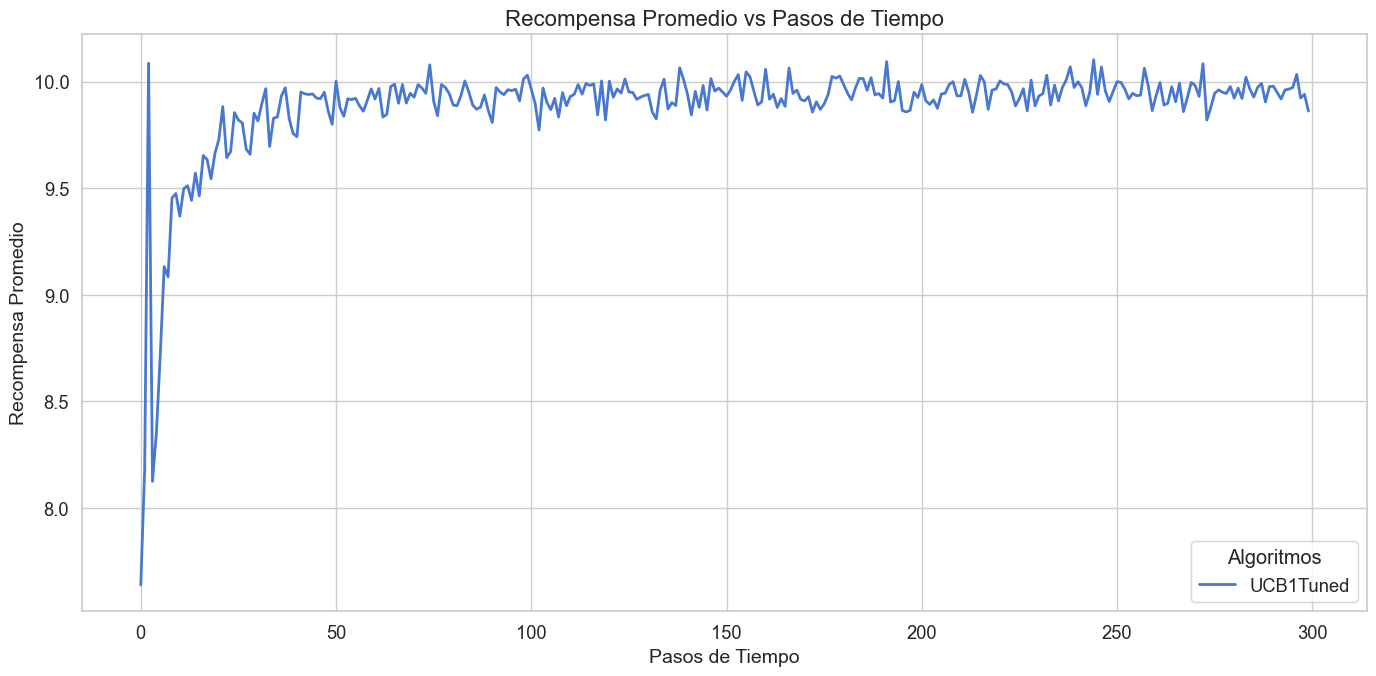

In [70]:
plot_average_rewards(steps, rewards_UCB1Tuned, algoritmos_UCB1Tuned)

Podemos observar que se obtienen unos valores de recompensa bastante similares a los de UCB1, obteniendo una recompensa promedia situada en torno a $10.0$. Esto evidencia que, efectivamente, la metodología de aprendizaje funciona.

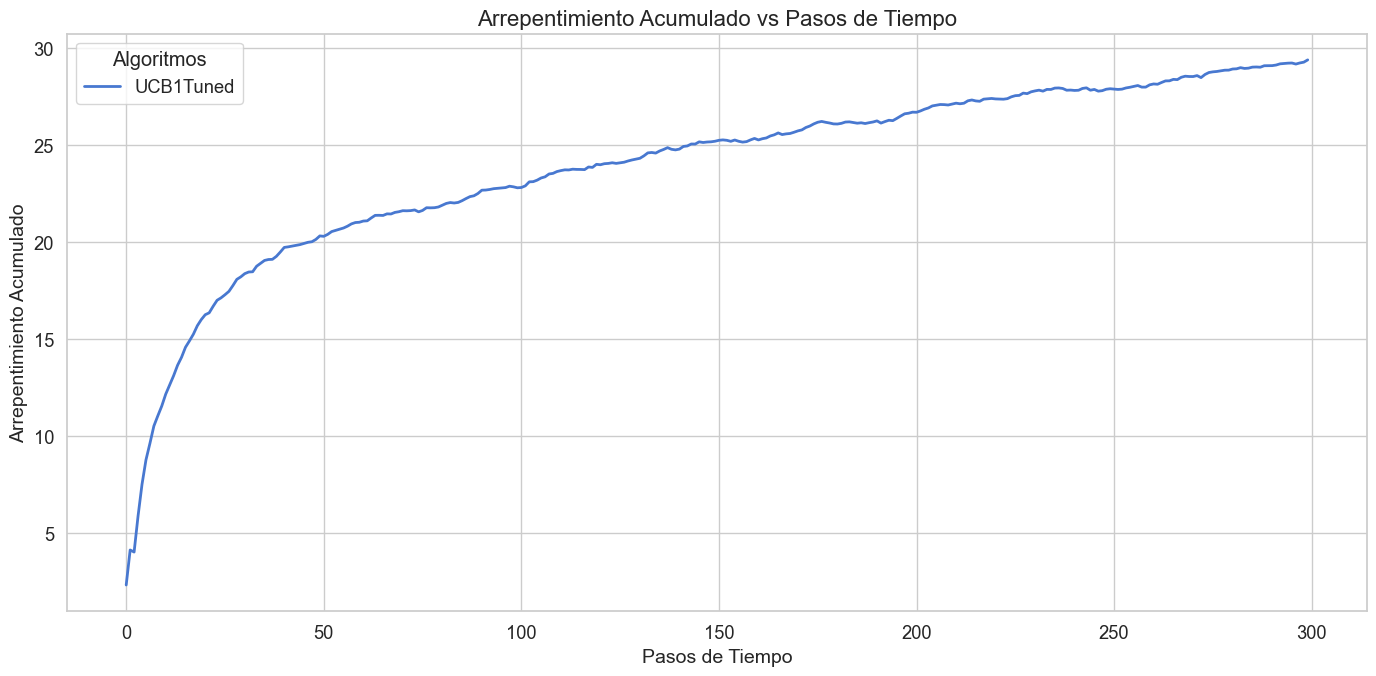

In [71]:
plot_regret(steps, cumulative_regret_per_algo_UCB1Tuned, algoritmos_UCB1Tuned)

Regresamos nuevamente a la curva logarítmica mencionada anteriormente para la curva del arrepentimiento. Vemos que la curva tiene un aspecto mucho más aplanado que UCB1, pero no tan bueno como UCB2.

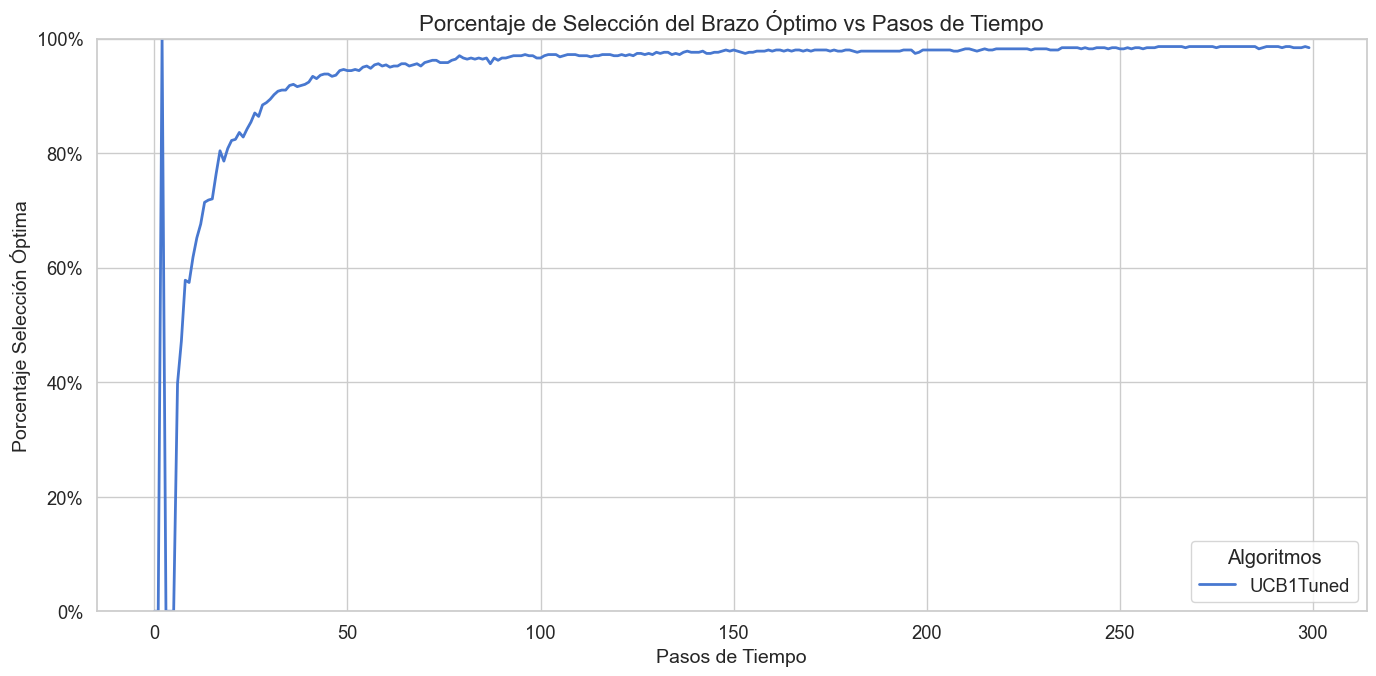

In [72]:
plot_optimal_selections(steps, optimal_selections_UCB1Tuned, algoritmos_UCB1Tuned)

Podemos observar que la curva del porcentaje de selección del brazo óptimo es bastante similar a la mejor curva obtenida con el algoritmo UCB1. Esto también evidencia que la curva es simplemente peor a la descrita en UCB2.

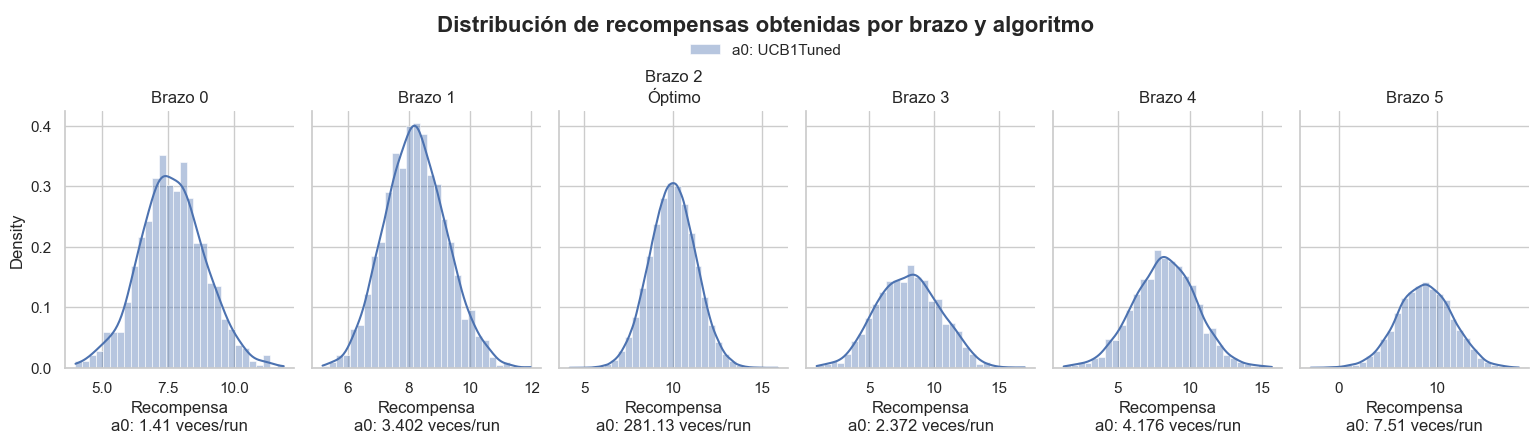

In [73]:
plot_arm_statistics(rewards_per_arm_per_algo_UCB1Tuned, algoritmos_UCB1Tuned, runs, optimal_arm_normal)

Podemos observar que el brazo óptimo es el que es más seleccionado dentro de todos los brazos. También vemos que el segundo brazo más seleccionado es el Brazo 5. De todos modos estos resultados son peores que los ya obtenidos con UCB2.

### Distribución Binomial

Ahora, es el turno del análisis del bandido con distribución binomial.

In [74]:
np.random.seed(SEMILLA)
rewards_BC1Tuned_Bi, optimal_selections_BC1Tuned_Bi, cumulative_regret_per_algo_BC1Tuned_Bi, rewards_per_arm_per_algo_BC1Tuned_Bi = run_experiment(bandit_binomial, algoritmos_UCB1Tuned, steps, runs)

100%|██████████| 500/500 [00:04<00:00, 110.67it/s]


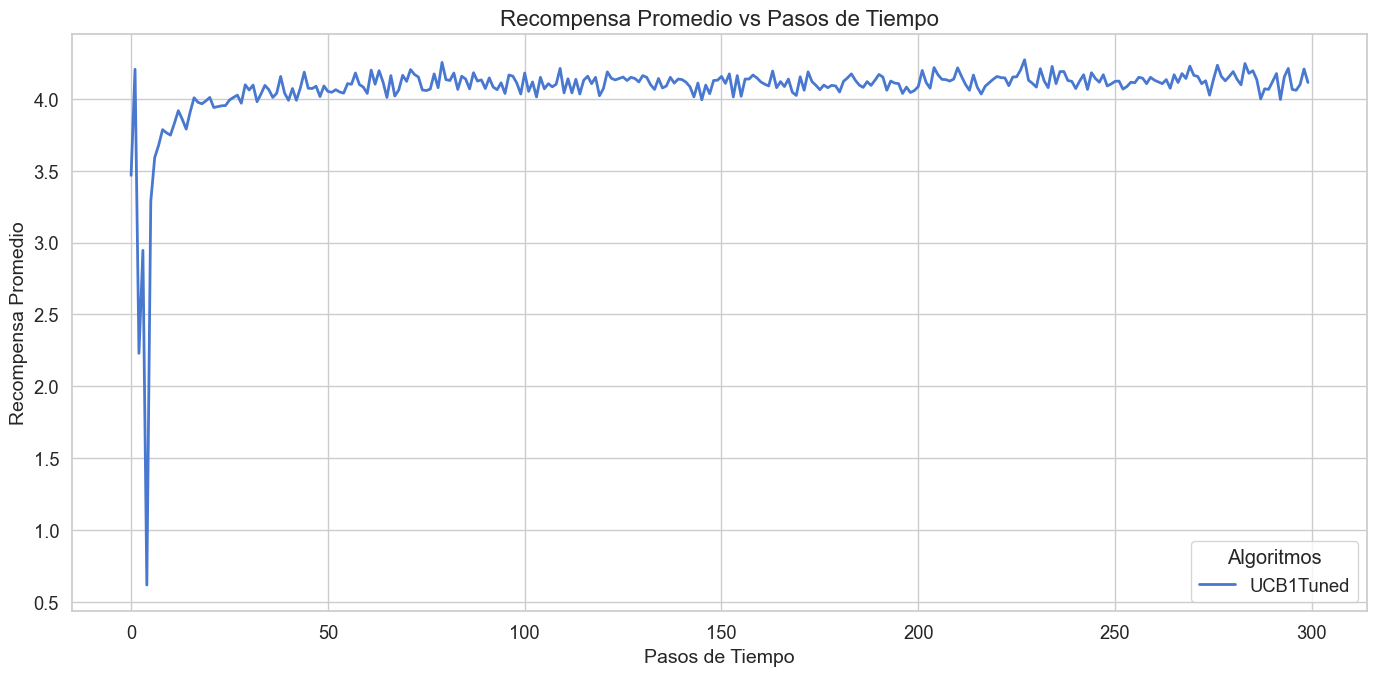

In [75]:
plot_average_rewards(steps, rewards_BC1Tuned_Bi, algoritmos_UCB1Tuned)

Como se puede observar se observa el mismo patrón de recompensa promedia visto con el algoritmo UCB1. A diferencia de UCB2, que funciona mal con este algoritmo, la convergencia claramente se evidencia y no hay estancamiento. La convergencia se establece en torno a la recompensa promedia de $4.0$.

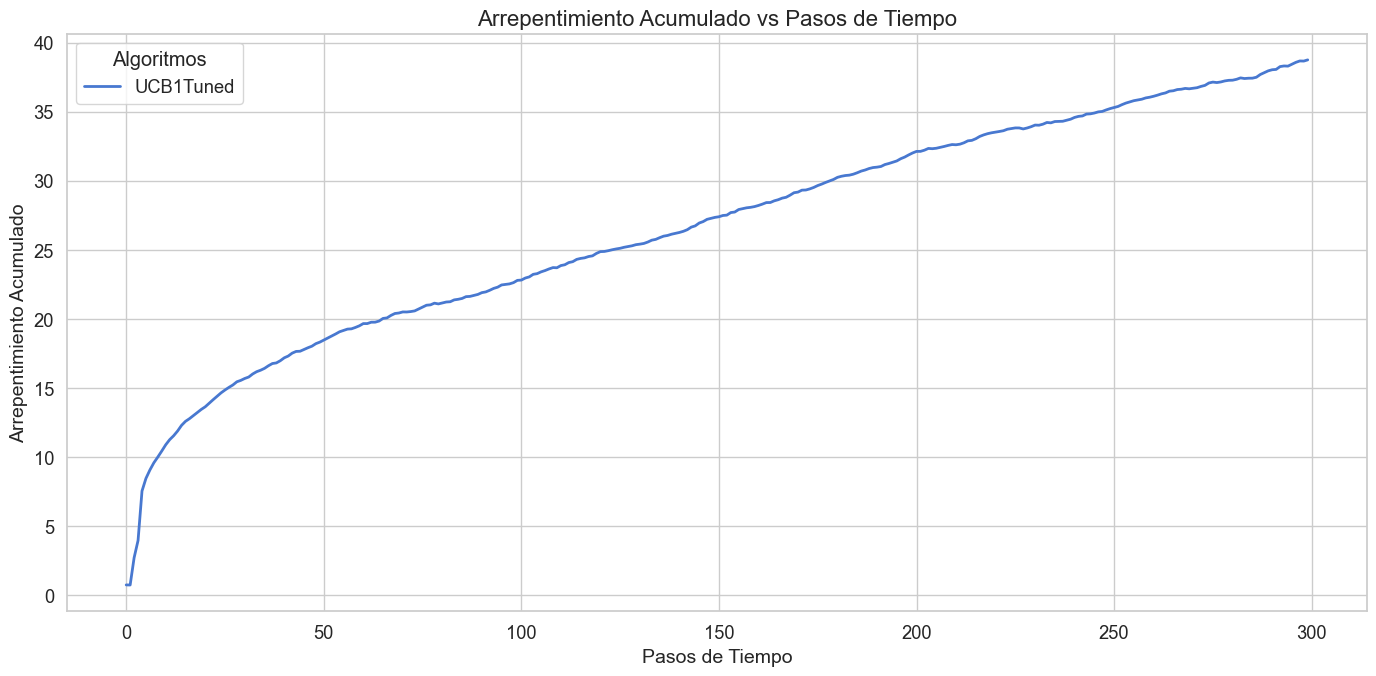

In [76]:
plot_regret(steps, cumulative_regret_per_algo_BC1Tuned_Bi, algoritmos_UCB1Tuned)

Eso sí, podemos observar con la curva de arrepentimiento que tiene aun menos forma logarítmica que con la anterior distribución. Se observa una tendencia aproximada de línea recta del arrepentimiento acumulado en torno a los 50 pasos de tiempo. El arrepentimiento acumulado para los 300 pasos tiene un valor inferior a los observados en UCB1.

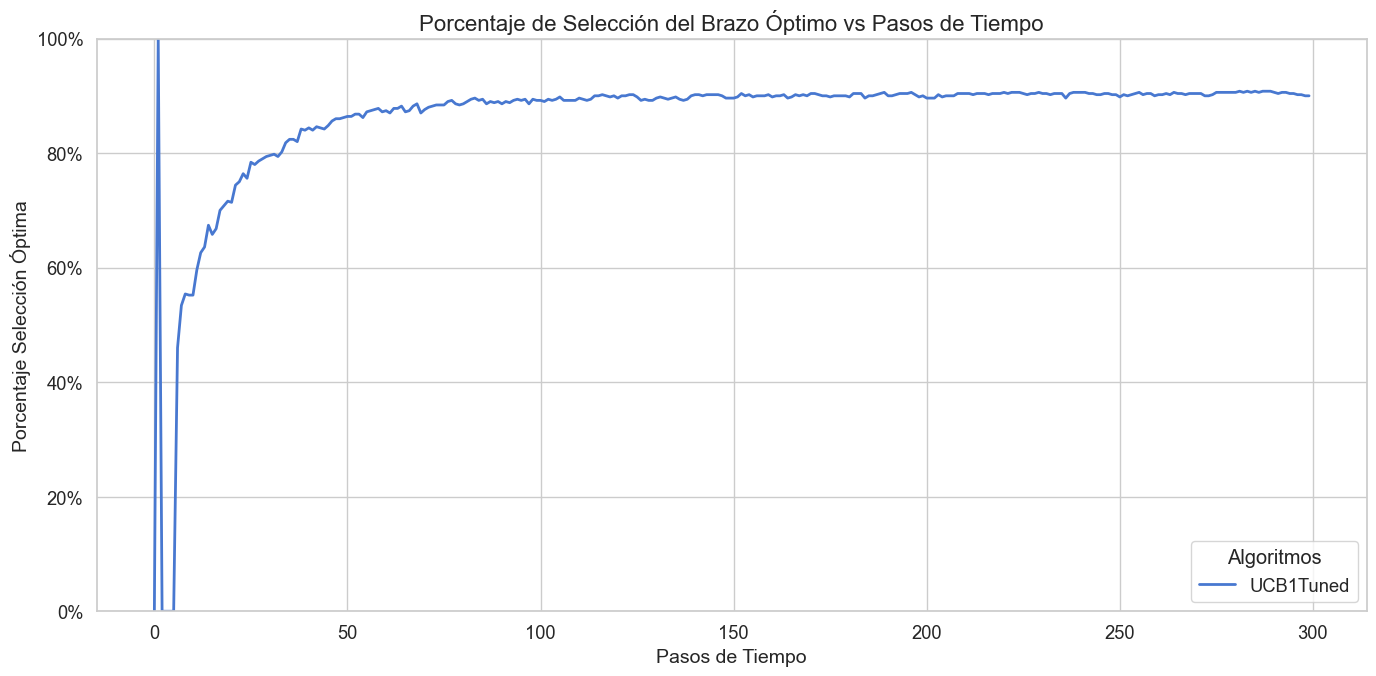

In [77]:
plot_optimal_selections(steps, optimal_selections_BC1Tuned_Bi, algoritmos_UCB1Tuned)

Respecto al porcentaje de selección del brazo óptimo respecto a los pasos de tiempo, podemos ver que la curva que sigue es bastante parecida a la descrita con el mismo brazo en el caso de UCB1. Además, vemos que se sitúa el porcentaje de selección del brazo óptimo en torno al 90%.

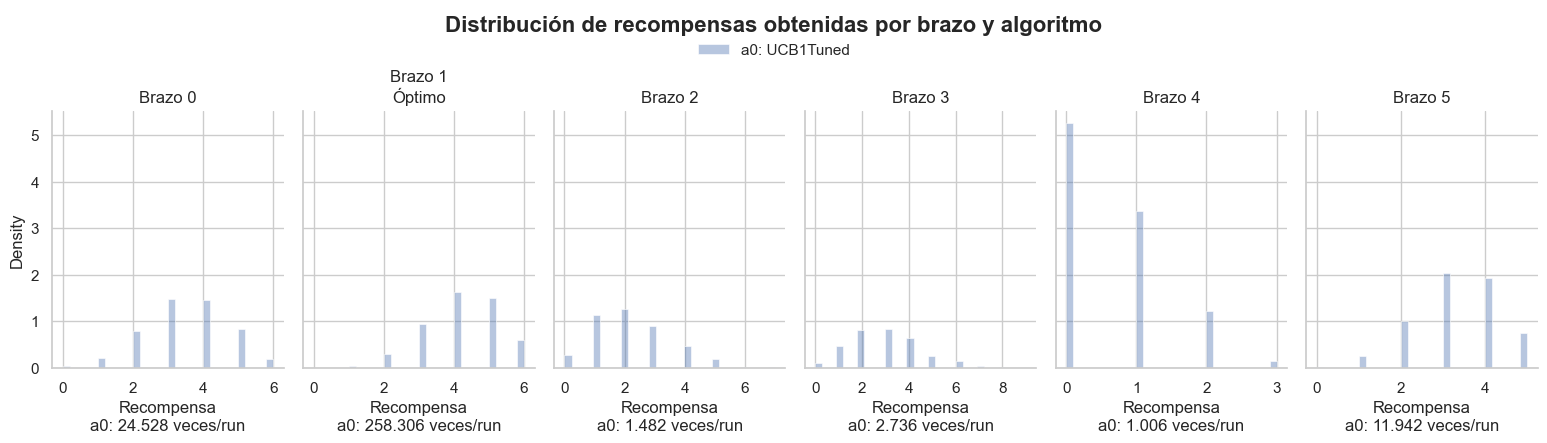

In [78]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1Tuned_Bi, algoritmos_UCB1Tuned, runs, optimal_arm_binomial, kde=False)

Respecto a la distribución de recompensas obtenidas, podemos ver que el brazo óptimo es el que tiene tendencia a ser el más elegido y vemos que curiosamente, uno de los brazos no óptimos es, relativamente hablando, bastante seleccionado, siendo este el Brazo 0. El siguiente brazo más seleccionado es el Brazo 5 y el resto de los brazos apenas son escogidos.

### Distribución Bernoulli

Por último y para cerrar el análisis completo de algoritmos UCB, realizaremos el análisis de UCB1Tuned con el bandido de la distribución de Bernoulli.

In [79]:
np.random.seed(SEMILLA)
rewards_BC1Tuned_Be, optimal_selections_BC1Tuned_Be, cumulative_regret_per_algo_BC1Tuned_Be, rewards_per_arm_per_algo_BC1Tuned_Be = run_experiment(bandit_bernoulli, algoritmos_UCB1Tuned, steps, runs)

100%|██████████| 500/500 [00:04<00:00, 110.01it/s]


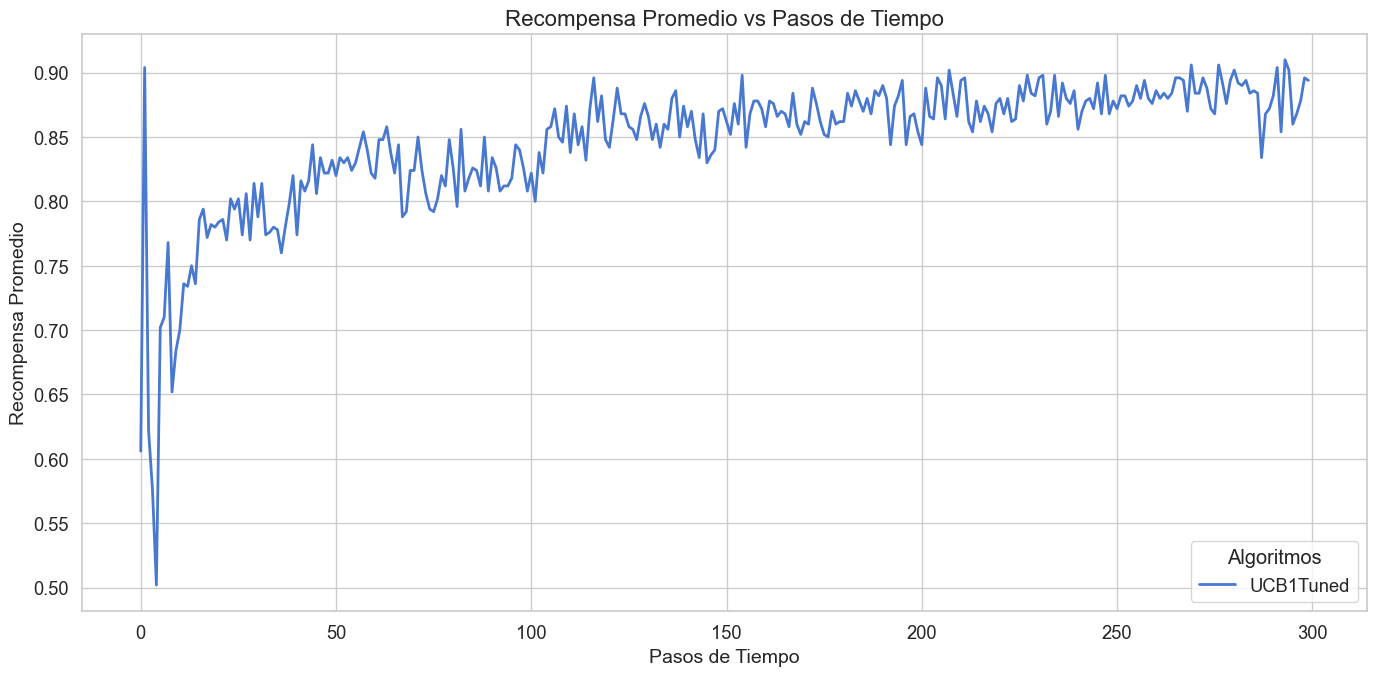

In [80]:
plot_average_rewards(steps, rewards_BC1Tuned_Be, algoritmos_UCB1Tuned)

La curva sigue una tendencia y valores bastantes parecidos que los descritos con UCB1, concretamente, con la versión de $c=0.5$. La recompensa estimada es de 0.9 aproximadamente.

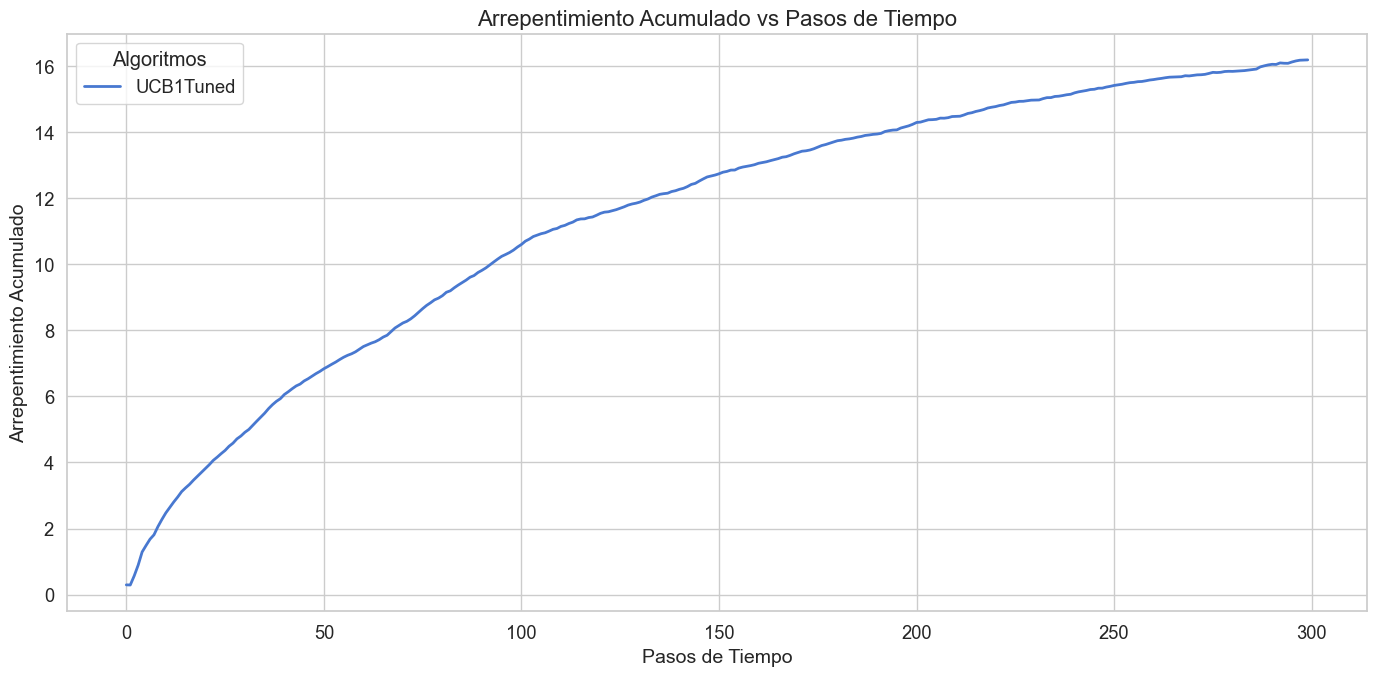

In [81]:
plot_regret(steps, cumulative_regret_per_algo_BC1Tuned_Be, algoritmos_UCB1Tuned)

El valor de arrepentimiento acumulado al final de los 300 pasos sigue una tendencia bastante parecida a los descritos por UCB1 para la misma distribución, y observamos una forma claramente logarítimica que parece continuar aplanándose durante los últimos pasos, lo que muestra un aprendizaje continuado. Parece tener valores de arrepentimiento incluso mejores que UCB para el valor de $c=0.5$.

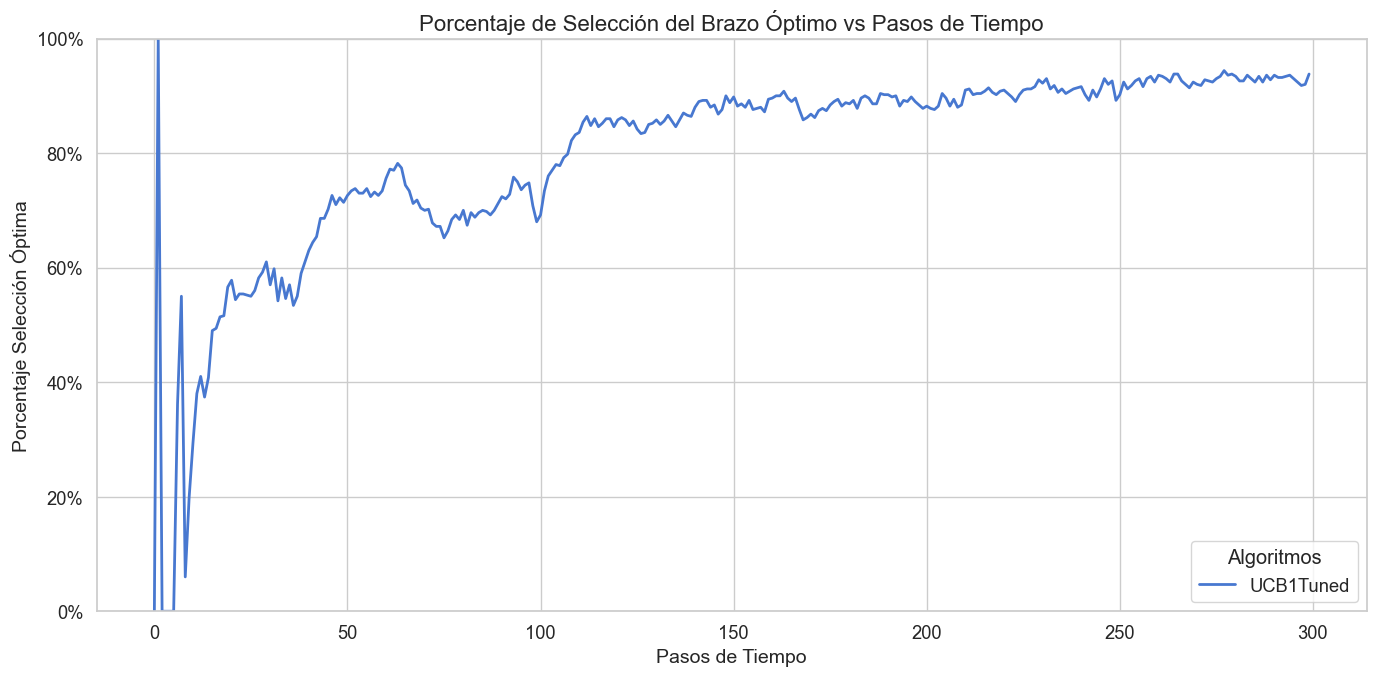

In [82]:
plot_optimal_selections(steps, optimal_selections_BC1Tuned_Be, algoritmos_UCB1Tuned)

Podemos observar que hasta que el algoritmo no llega a los 100 pasos, el porcentaje de selección del brazo óptimo para este algoritmo no llega a estabilizar, es decir, al algoritmo le cuesta inicialmente encontrar aquel brazo que sea el óptimo. Una vez que lo ha llegado a encotrar, es bastante seleccionado, estando el porcentaje de selección en torno al 95%.

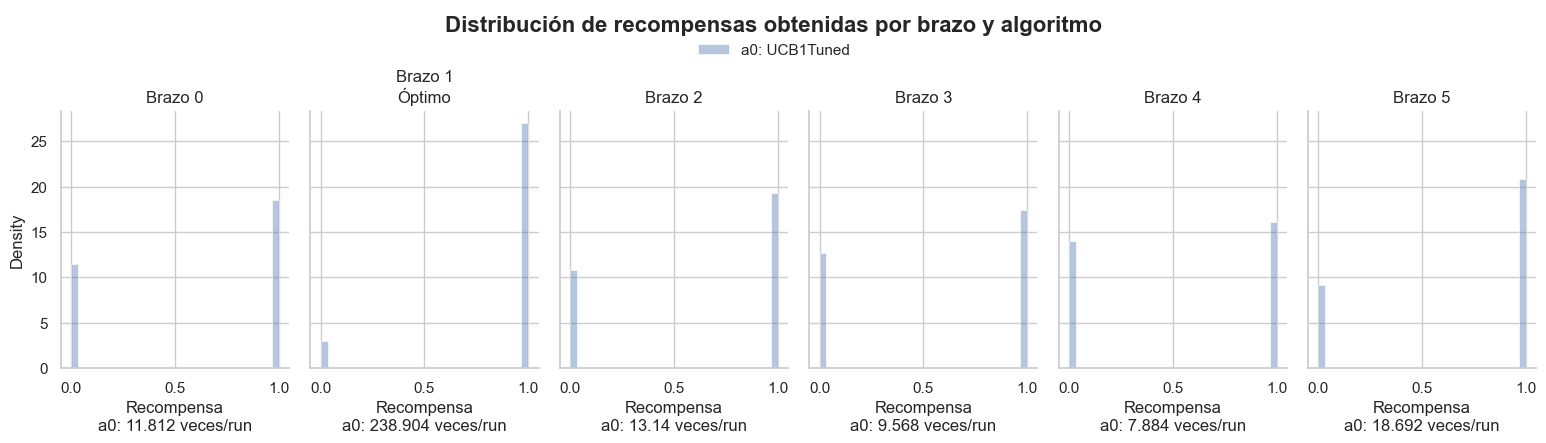

In [83]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1Tuned_Be, algoritmos_UCB1Tuned, runs, optimal_arm_bernoulli, kde=False)

Podemos ver que, evidentemente, el brazo que es más seleccionado es el brazo óptimo. También podemos ver que los dos siguientes mejores brazos, que son no óptimos, son igual de seleccionados respecto al brazo con la distribución binomial. Este patrón se replica en cierta manera con UCB1 con las mismas distribuciones.

## Conclusiones

En este estudio, lo que hemos hecho ha sido comparar y estudiar el comportamiento de 3 modelos escogidos de la familia de algoritmos UCB, en particular, UCB1, UCB2 y UCB1-Tuned. Cada algoritmo ha sido evaluado con bandidos de 6 brazos a través de cada una de las distribuciones propuestas, que son la normal, la binomial y Bernoulli y las conclusiones finales extraídas son las siguientes:

- El algoritmo UCB1 independientemente de las parametrizaciones escogidas para la exploración tiene un comportamiento extremadamente similar con el bandido de distribución normal, sin embargo, la diferencia se hace bastante más palpable conforme se utiliza la distribución binomial o la distribución de bernoulli. La parametrización que mejor funciona de forma global a través de todos los brazos es aquella cuando $\mathbf{c=0.5}$. Podemos observar que, de todos modos, el algoritmo que mejor funciona es con la versión normal, alcanzando un porcentaje de selección del brazo óptimo muy cercano al 100%.

- El algoritmo UCB2 tiene un rendimiento totalmente sobresaliente con el brazo de la distribución normal, obteniendo prácticamente desde el inicio una convergencia al porcentaje de selección del brazo óptimo del 100%. El arrepentimiento acumulado se nota disperso a consecuencia de tener un arrepentimiento muy bajo, sin embargo, aquel que muestra mejor arrepentimiento se da cuando $\alpha=0.75$. Los brazos no óptimos son solamente seleccionados en la distribución normal cuando se realiza la exploración de estos. También observamos que el algoritmo funciona muy mal cuando se utilizan bandidos con distribución binomial o de bernoulli, llegando a estancamientos y no logrando encontrar el brazo que resulte óptimo. A través de cada una de las parametrizaciones en cada brazo que no siga la distribución normal, rara vez es seleccionado el brazo óptimo.

- El algoritmo UCB1-Tuned si bien no admite parametrizaciones, observamos un funcionamiento bastante similar al de UCB1, con muy buenos resultados, pero no tan sobresalientes como los de UCB2 en el caso normal. Este algoritmo no tiene los problemas que tiene UCB2 respecto a las convergencias en distribuciones con recompensas discretas. Observamos, eso sí, que el algoritmo tiene tendencia a costarle más encontrar el brazo óptimo respecto a UCB1, aunque suele alcanzar recompensas ligeramente superiores.

Con todo esto, queda evidentemente demostrado que UCB2 es la solución más potente dentro de la familia de algoritmos cuando la distribución del bandido es normal, mientras que UCB1-Tuned es la mejor opción en bandidos con recompensas discretas. Además, comprobamos lo altamente versátiles que pueden ser los algoritmos UCB.